<a href="https://colab.research.google.com/github/Rharrabirihab/Pr-diction_Panne_Komax/blob/main/Visualisation_Komax_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from sklearn.feature_selection import SelectKBest, f_regression
sns.set_style("whitegrid")
%matplotlib inline

### Accessing Data from Google Drive

Since the data file is located on Google Drive, we need to first mount Google Drive to access its contents from this Colab notebook. Then, we will use `gdown` to download the specific file.

In [17]:
# Install gdown to easily download files from Google Drive
!pip install gdown -q

In [18]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Download the file using its ID from the provided Google Drive link
# The file ID is '1pPD3dPhtRMxKxmQJidevRdaPpsVPEMyk'
import os

file_id = '1pPD3dPhtRMxKxmQJidevRdaPpsVPEMyk'
output_filename = 'DataKomax_Corrective.csv'

print(f"Attempting to download '{output_filename}'...")
!gdown --id $file_id -O $output_filename

if os.path.exists(output_filename):
    print(f"File '{output_filename}' successfully downloaded to the Colab environment.")
else:
    print(f"Failed to download '{output_filename}'. Please ensure the Google Drive file permissions are set to 'Anyone with the link'.")

Attempting to download 'DataKomax_Corrective.csv'...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1pPD3dPhtRMxKxmQJidevRdaPpsVPEMyk

but Gdown can't. Please check connections and permissions.
Failed to download 'DataKomax_Corrective.csv'. Please ensure the Google Drive file permissions are set to 'Anyone with the link'.


In [20]:
DataKomax_Corrective=pd.read_csv('/content/drive/MyDrive/Projet_Maintenance_Komax/DataKomax_Corrective.csv') # Loading from the specified Google Drive path

In [21]:
print(f"Train shape: {DataKomax_Corrective.shape}")

Train shape: (18323, 30)


In [22]:
print("Données netoyée:")
display(DataKomax_Corrective.head())

Données netoyée:


,Machine,Type Of Failure,Defect Code,Microstop Description,Type,Declaration Start Time,Call Maintenance Time,Intervention Start Time,Declaration End Time,Down Time,...,Total Maintenance Time (min),Hour,Shift,Comment_Clean,Equipe,Technicien_Nom,Chef_Equipe,Shift_Reel,Semaine,Defect_Label
0,KOMAX_5,MARQUAGE,MR05,P-Marquage illisible,Maintenance,2025-04-01 22:21:29,2025-04-01 22:21:35,2025-04-01 22:25:08,2025-04-01 22:31:16.670,00:09:41,...,9.69,22.0,Nuit,RINCAGE BUSE MARQUAGE,Equipe_1,KENDI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MR05 — P-Marquage illisible
1,KOMAX_46,MINI-APPLICATEUR,MAP05,P-Pincement fil /Joint,Maintenance,2025-04-01 22:33:19,2025-04-01 22:34:37,2025-04-01 22:38:26,2025-04-01 22:46:20.377,00:11:43,...,11.72,22.0,Nuit,REGLAGE POSITION + REGLAGE TIGE,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP05 — P-Pincement fil /Joint
2,KOMAX_24,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 22:53:15,2025-04-01 22:53:21,2025-04-01 22:58:02,2025-04-01 23:42:43.813,00:49:22,...,49.38,22.0,Nuit,REGLAGE BELLMOUTH TÉMOIN,Equipe_1,FAKHRANE,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP03 — P-Bellmouth/Témoin
3,KOMAX_17,MINI-APPLICATEUR,MAP02,P-Déformation connexion,Maintenance,2025-04-01 23:00:24,2025-04-01 23:00:27,2025-04-01 23:11:13,2025-04-01 23:16:54.623,00:16:27,...,16.46,23.0,Nuit,CENTRAG ENTRAINEMENT CONNEXION+REGLAGE BELLMOU...,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP02 — P-Déformation connexion
4,KOMAX_43,MINI-APPLICATEUR,MAP03,P-Bellmouth/Témoin,Maintenance,2025-04-01 23:00:30,2025-04-01 23:00:32,2025-04-01 23:23:44,2025-04-01 23:32:02.633,00:31:30,...,31.51,23.0,Nuit,REGLAGE BELLMOUTH TÉMOIN+REGLAGE CLIQUET+AJUST...,Equipe_1,KAMILI,{'5683': 'AITSALAH RACHID'},Nuit,2025-W14,MAP03 — P-Bellmouth/Témoin


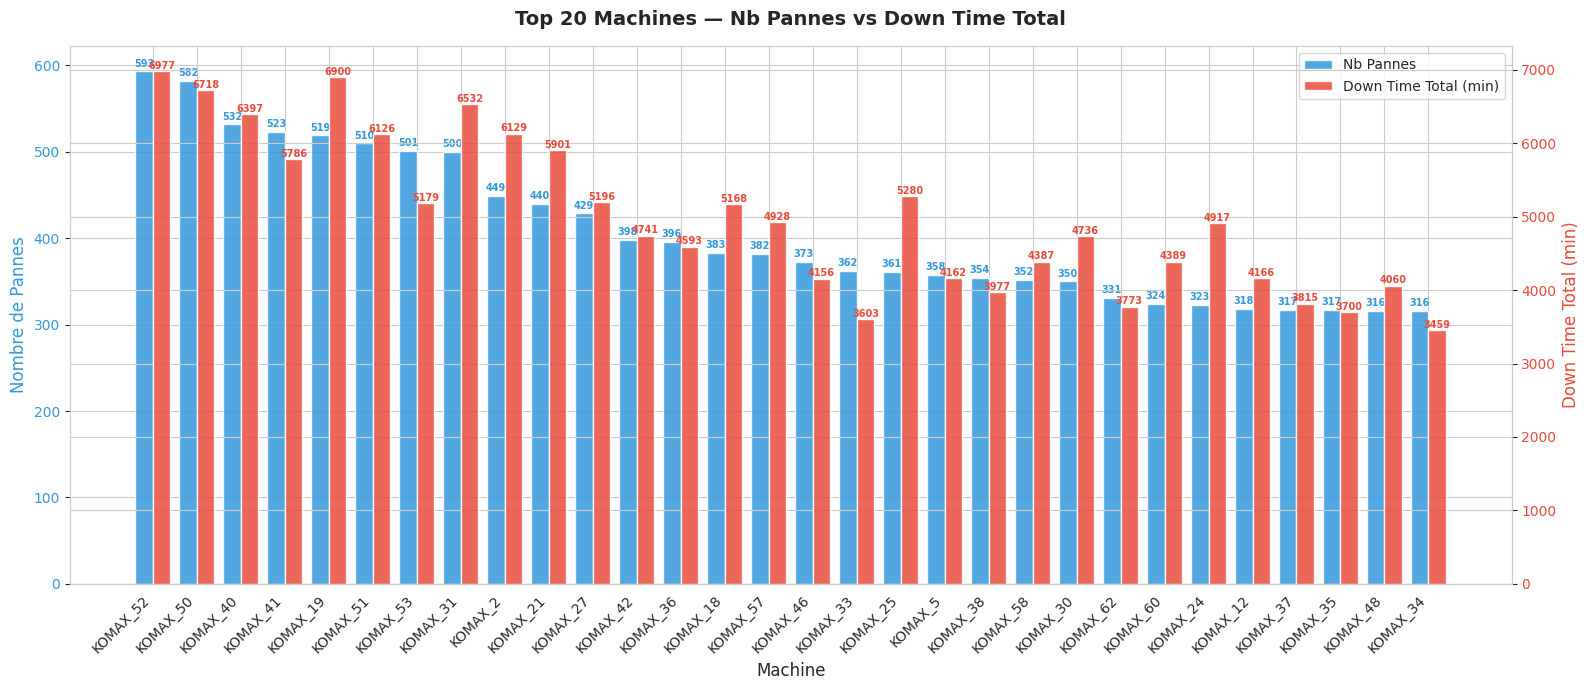

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ── Préparer les données ────────────────────────
top20 = (DataKomax_Corrective.groupby('Machine')
         .agg(
             Nb_Pannes   = ('Down Time (min)', 'count'),
             Down_Time   = ('Down Time (min)', 'sum')
         )
         .sort_values('Nb_Pannes', ascending=False)
         .head(30)
         .reset_index())

machines  = top20['Machine']
nb_pannes = top20['Nb_Pannes']
down_time = top20['Down_Time']

x = np.arange(len(machines))
width = 0.4

# ── Graphe double axe Y ─────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))

# ── Axe gauche : Nb Pannes ──────────────────────
bars1 = ax1.bar(x - width/2, nb_pannes,
                width=width,
                color='#3498db',
                label='Nb Pannes',
                alpha=0.85)
ax1.set_xlabel('Machine', fontsize=12)
ax1.set_ylabel('Nombre de Pannes', fontsize=12,
               color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels(machines, rotation=45, ha='right')

# Valeurs sur barres Nb Pannes
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             str(int(bar.get_height())),
             ha='center', va='bottom',
             fontsize=7, color='#3498db',
             fontweight='bold')

# ── Axe droit : Down Time ───────────────────────
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, down_time,
                width=width,
                color='#e74c3c',
                label='Down Time Total (min)',
                alpha=0.85)
ax2.set_ylabel('Down Time Total (min)', fontsize=12,
               color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Valeurs sur barres Down Time
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{int(bar.get_height())}',
             ha='center', va='bottom',
             fontsize=7, color='#e74c3c',
             fontweight='bold')

# ── Titre et légende ────────────────────────────
plt.title('Top 20 Machines — Nb Pannes vs Down Time Total',
           fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('top20_double_axe.png', dpi=150)
plt.show()

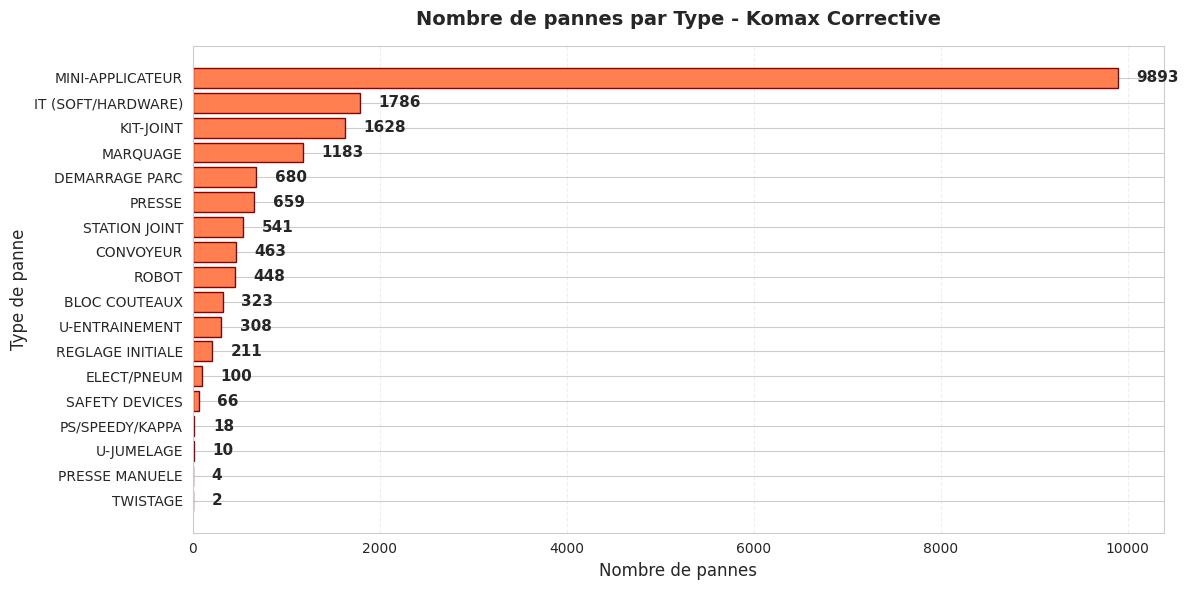

In [24]:
type_counts = DataKomax_Corrective['Type Of Failure'].value_counts()

# ========== GRAPHIQUE 1 : BARPLOT HORIZONTAL (seul) ==========
fig1, ax1 = plt.subplots(figsize=(12, 6))
fig1.patch.set_facecolor('white')

type_counts_sorted = type_counts.sort_values(ascending=True)
bars = ax1.barh(type_counts_sorted.index, type_counts_sorted.values,
                color='coral', edgecolor='darkred', linewidth=1)
ax1.set_title('Nombre de pannes par Type - Komax Corrective',
              fontweight='bold', fontsize=14, pad=15)
ax1.set_xlabel('Nombre de pannes', fontsize=12)
ax1.set_ylabel('Type de panne', fontsize=12)

for bar, v in zip(bars, type_counts_sorted.values):
    ax1.text(v + max(type_counts_sorted.values) * 0.02,
             bar.get_y() + bar.get_height()/2,
             f'{int(v)}', va='center', ha='left', fontsize=11, fontweight='bold')

ax1.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('type_panne_bars.png', dpi=300, bbox_inches='tight')
plt.show()



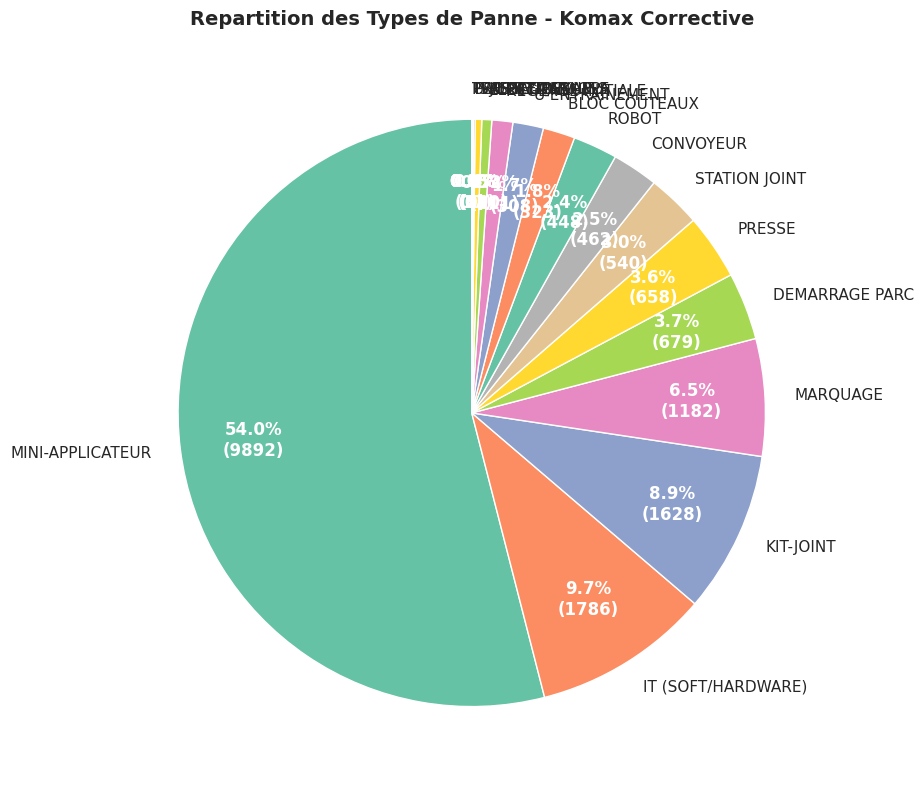

In [25]:
# ========== GRAPHIQUE 2 : PIE CHART (seul) ==========
fig2, ax2 = plt.subplots(figsize=(10, 8))
fig2.patch.set_facecolor('white')

total = type_counts.sum()
colors = sns.color_palette('Set2', len(type_counts))

wedges, texts, autotexts = ax2.pie(type_counts.values,
                                    labels=type_counts.index,
                                    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total)})',
                                    startangle=90,
                                    colors=colors,
                                    textprops={'fontsize': 11},
                                    pctdistance=0.75,
                                    labeldistance=1.1)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax2.set_title('Repartition des Types de Panne - Komax Corrective',
              fontweight='bold', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig('type_panne_pie.png', dpi=300, bbox_inches='tight')
plt.show()

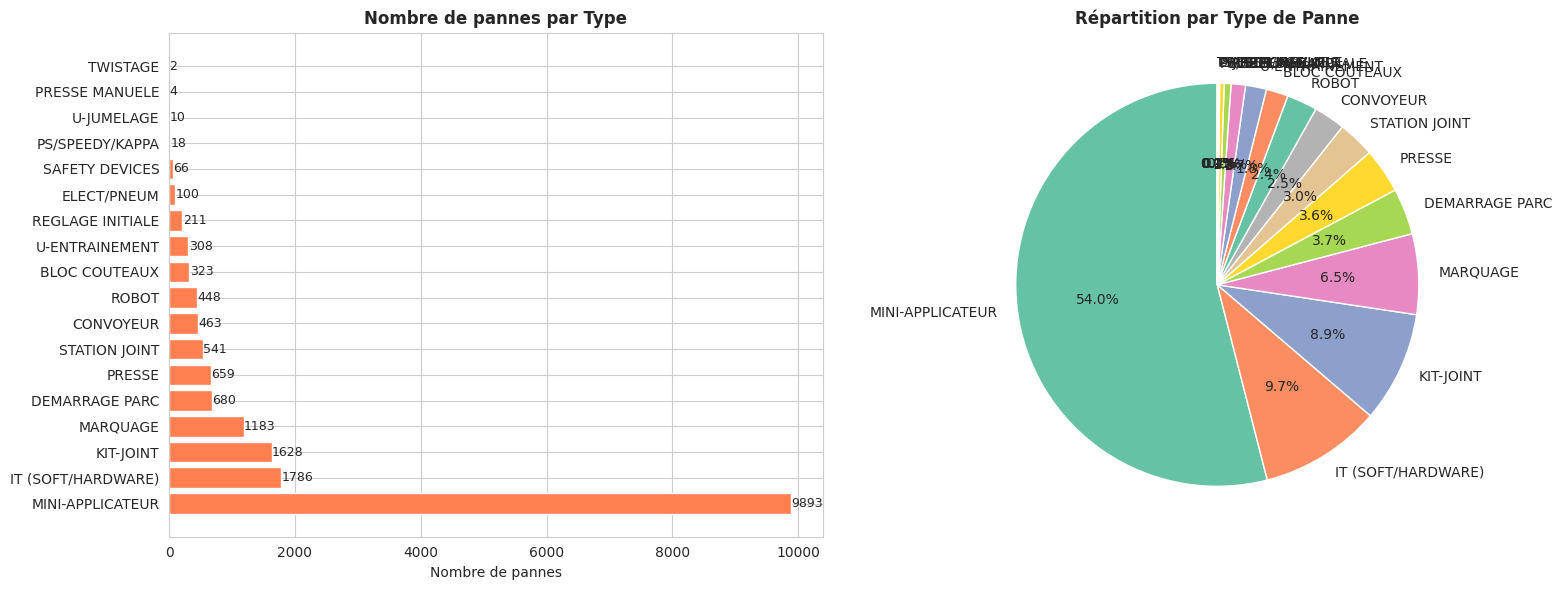

In [26]:
type_counts = DataKomax_Corrective['Type Of Failure'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
axes[0].barh(type_counts.index, type_counts.values, color='coral')
axes[0].set_title('Nombre de pannes par Type', fontweight='bold')
axes[0].set_xlabel('Nombre de pannes')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)
# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(type_counts)))
axes[1].set_title('Répartition par Type de Panne', fontweight='bold')

plt.tight_layout()
plt.savefig('type_panne.png', dpi=150)
plt.show()



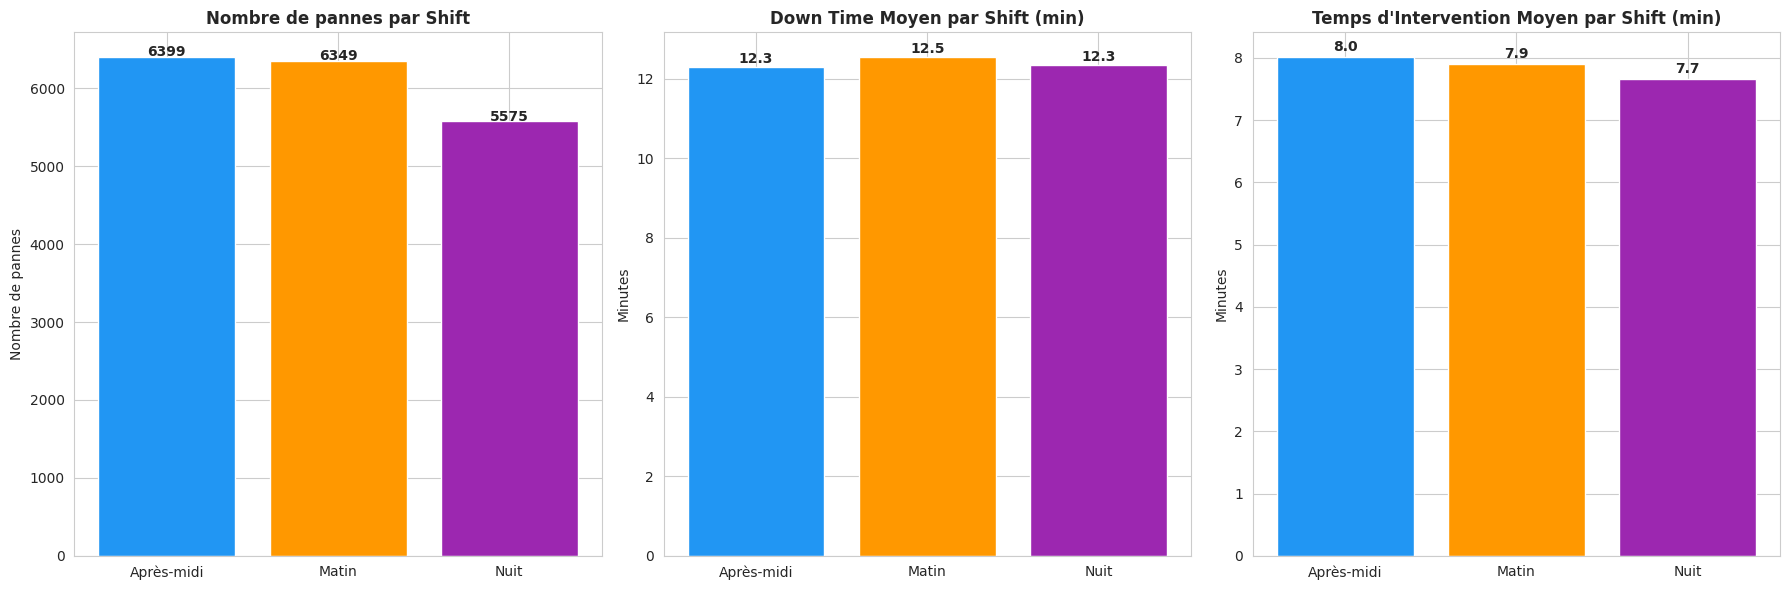

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Nombre de pannes par shift
shift_counts = DataKomax_Corrective['Shift'].value_counts()
colors_shift = ['#2196F3', '#FF9800', '#9C27B0']

axes[0].bar(shift_counts.index, shift_counts.values, color=colors_shift)
axes[0].set_title('Nombre de pannes par Shift', fontweight='bold')
axes[0].set_ylabel('Nombre de pannes')
for i, v in enumerate(shift_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Down Time moyen par shift
shift_down = DataKomax_Corrective.groupby('Shift')['Down Time (min)'].mean().round(2)
axes[1].bar(shift_down.index, shift_down.values, color=colors_shift)
axes[1].set_title('Down Time Moyen par Shift (min)', fontweight='bold')
axes[1].set_ylabel('Minutes')
for i, v in enumerate(shift_down.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Intervention Time moyen par shift
shift_interv = DataKomax_Corrective.groupby('Shift')['Intervention Time (min)'].mean().round(2)
axes[2].bar(shift_interv.index, shift_interv.values, color=colors_shift)
axes[2].set_title("Temps d'Intervention Moyen par Shift (min)", fontweight='bold')
axes[2].set_ylabel('Minutes')
for i, v in enumerate(shift_interv.values):
    axes[2].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('shift_analysis.png', dpi=150)
plt.show()

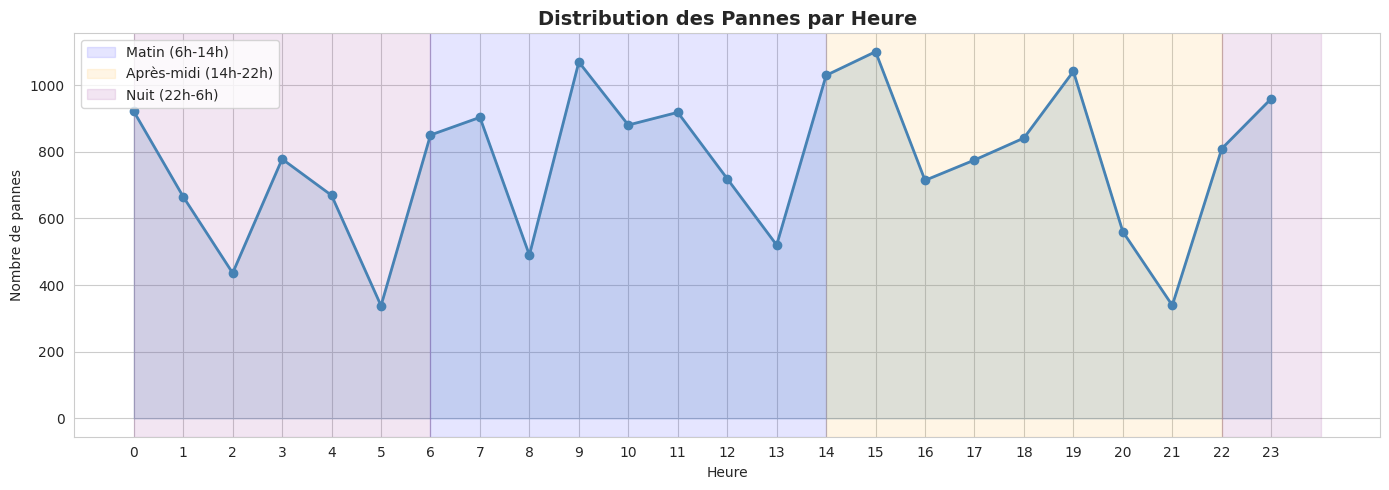

In [28]:
plt.figure(figsize=(14, 5))
hour_counts = DataKomax_Corrective['Hour'].value_counts().sort_index()

plt.plot(hour_counts.index, hour_counts.values,
         marker='o', linewidth=2, color='steelblue', markersize=6)
plt.fill_between(hour_counts.index, hour_counts.values, alpha=0.2, color='steelblue')

# Zones shift
plt.axvspan(6, 14, alpha=0.1, color='blue', label='Matin (6h-14h)')
plt.axvspan(14, 22, alpha=0.1, color='orange', label='Après-midi (14h-22h)')
plt.axvspan(0, 6, alpha=0.1, color='purple', label='Nuit (22h-6h)')
plt.axvspan(22, 24, alpha=0.1, color='purple')

plt.title('Distribution des Pannes par Heure', fontsize=14, fontweight='bold')
plt.xlabel('Heure')
plt.ylabel('Nombre de pannes')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig('pannes_par_heure.png', dpi=150)
plt.show()

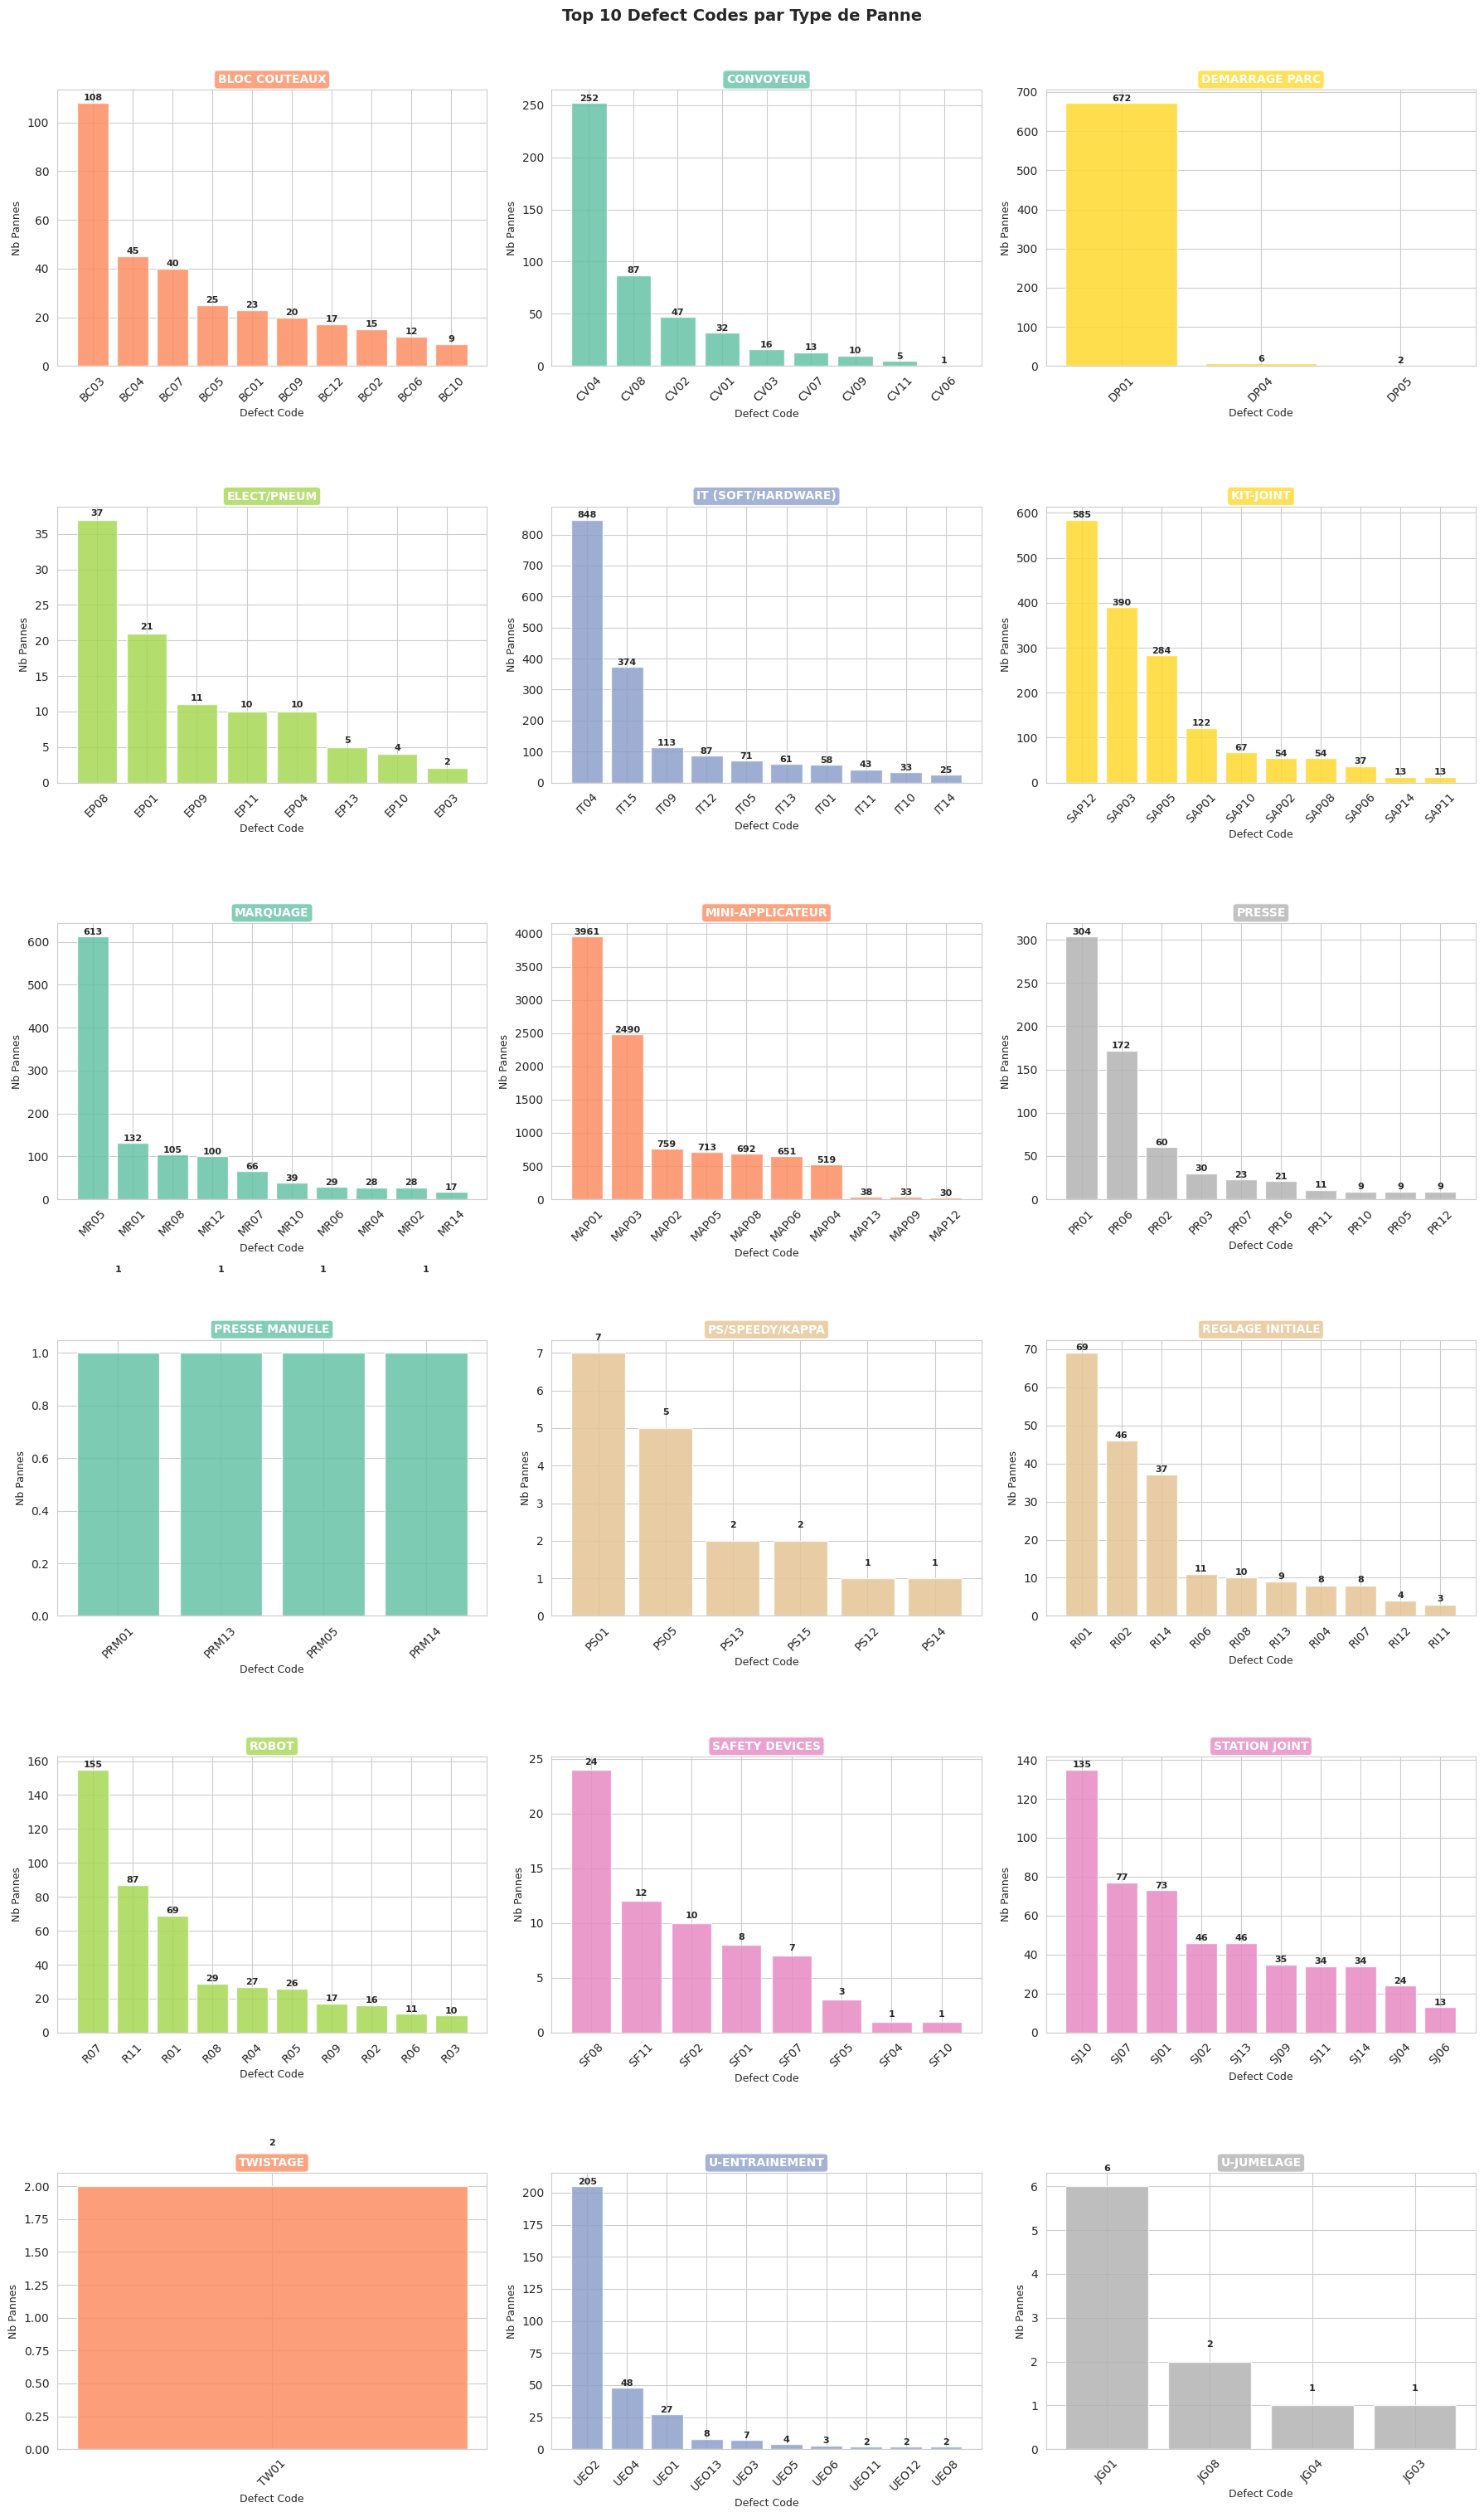

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Version 1 : Subplots séparés par Type Of Failure ──
types = DataKomax_Corrective['Type Of Failure'].unique()
n     = len(types)
cols  = 3
rows  = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols,
                          figsize=(18, rows * 5))
axes = axes.flatten()

colors_map = {t: c for t, c in zip(
    types,
    sns.color_palette('Set2', len(types))
)}

for i, type_panne in enumerate(sorted(types)):
    ax   = axes[i]
    data = (DataKomax_Corrective[
                DataKomax_Corrective['Type Of Failure'] == type_panne
            ]['Defect Code']
            .value_counts()
            .head(10))

    if len(data) == 0:
        ax.set_visible(False)
        continue

    bars = ax.bar(data.index, data.values,
                  color=colors_map[type_panne],
                  alpha=0.85, edgecolor='white')

    ax.set_title(f'{type_panne}',
                  fontweight='bold', fontsize=10,
                  color='white',
                  bbox=dict(boxstyle='round,pad=0.3',
                            facecolor=colors_map[type_panne],
                            alpha=0.8))
    ax.set_xlabel('Defect Code', fontsize=9)
    ax.set_ylabel('Nb Pannes', fontsize=9)
    ax.tick_params(axis='x', rotation=45)

    # Valeurs sur barres
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(val), ha='center', va='bottom',
                fontsize=8, fontweight='bold')

# Masquer les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Defect Codes par Type de Panne',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('defects_par_type.png', dpi=150, bbox_inches='tight')
plt.show()

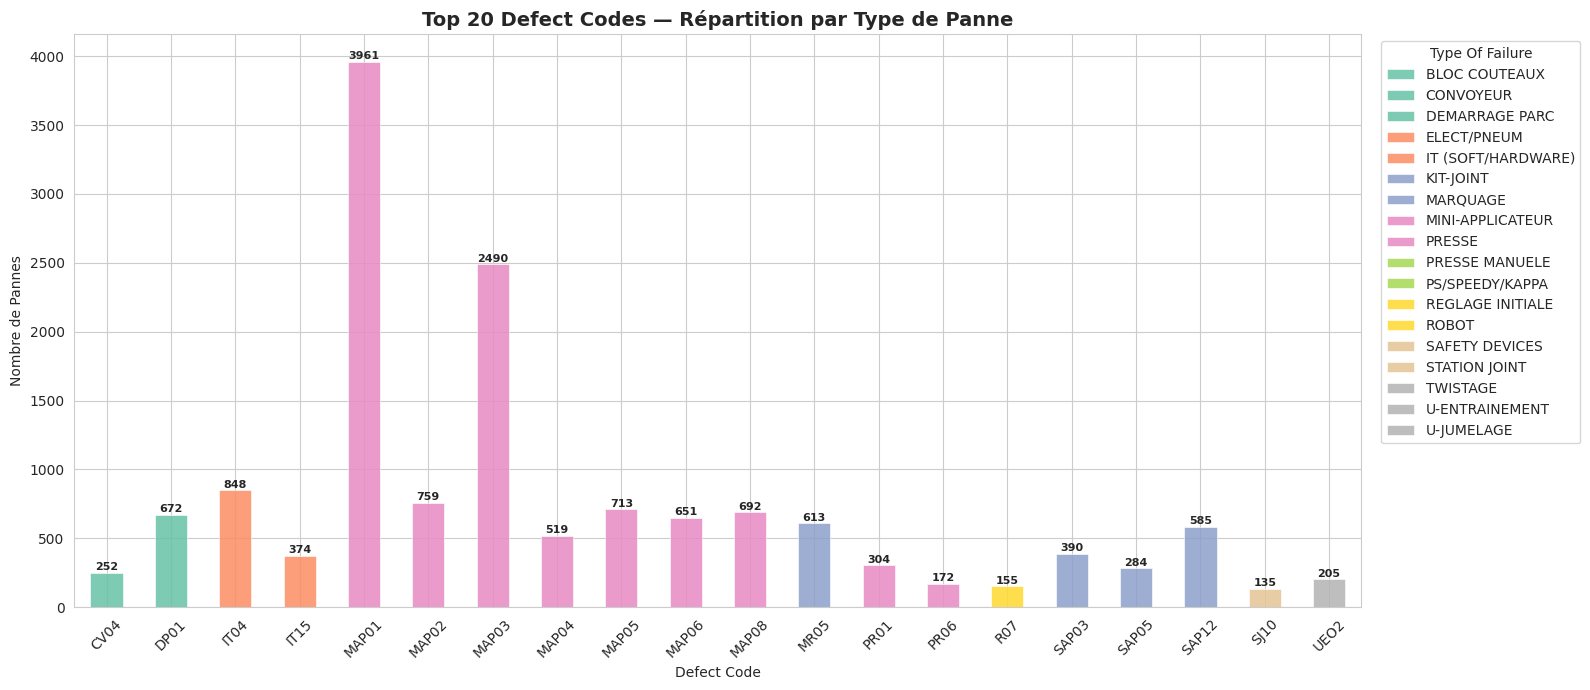

In [30]:
# ── Version 2 : Stacked bar — tous types ensemble ──
pivot = (DataKomax_Corrective
         .groupby(['Defect Code', 'Type Of Failure'])
         .size()
         .unstack(fill_value=0))

# Top 20 defect codes
top20_idx = (DataKomax_Corrective['Defect Code']
             .value_counts().head(20).index)
pivot_top  = pivot.loc[pivot.index.isin(top20_idx)]

fig, ax = plt.subplots(figsize=(16, 7))
pivot_top.plot(
    kind='bar', stacked=True, ax=ax,
    colormap='Set2', alpha=0.85,
    edgecolor='white', linewidth=0.5)

ax.set_title('Top 20 Defect Codes — Répartition par Type de Panne',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Defect Code')
ax.set_ylabel('Nombre de Pannes')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type Of Failure',
          bbox_to_anchor=(1.01, 1), loc='upper left')

# Total sur chaque barre
totals = pivot_top.sum(axis=1)
for i, (idx, val) in enumerate(totals.items()):
    ax.text(i, val + 2, str(int(val)),
            ha='center', va='bottom',
            fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('defects_stacked.png', dpi=150)
plt.show()

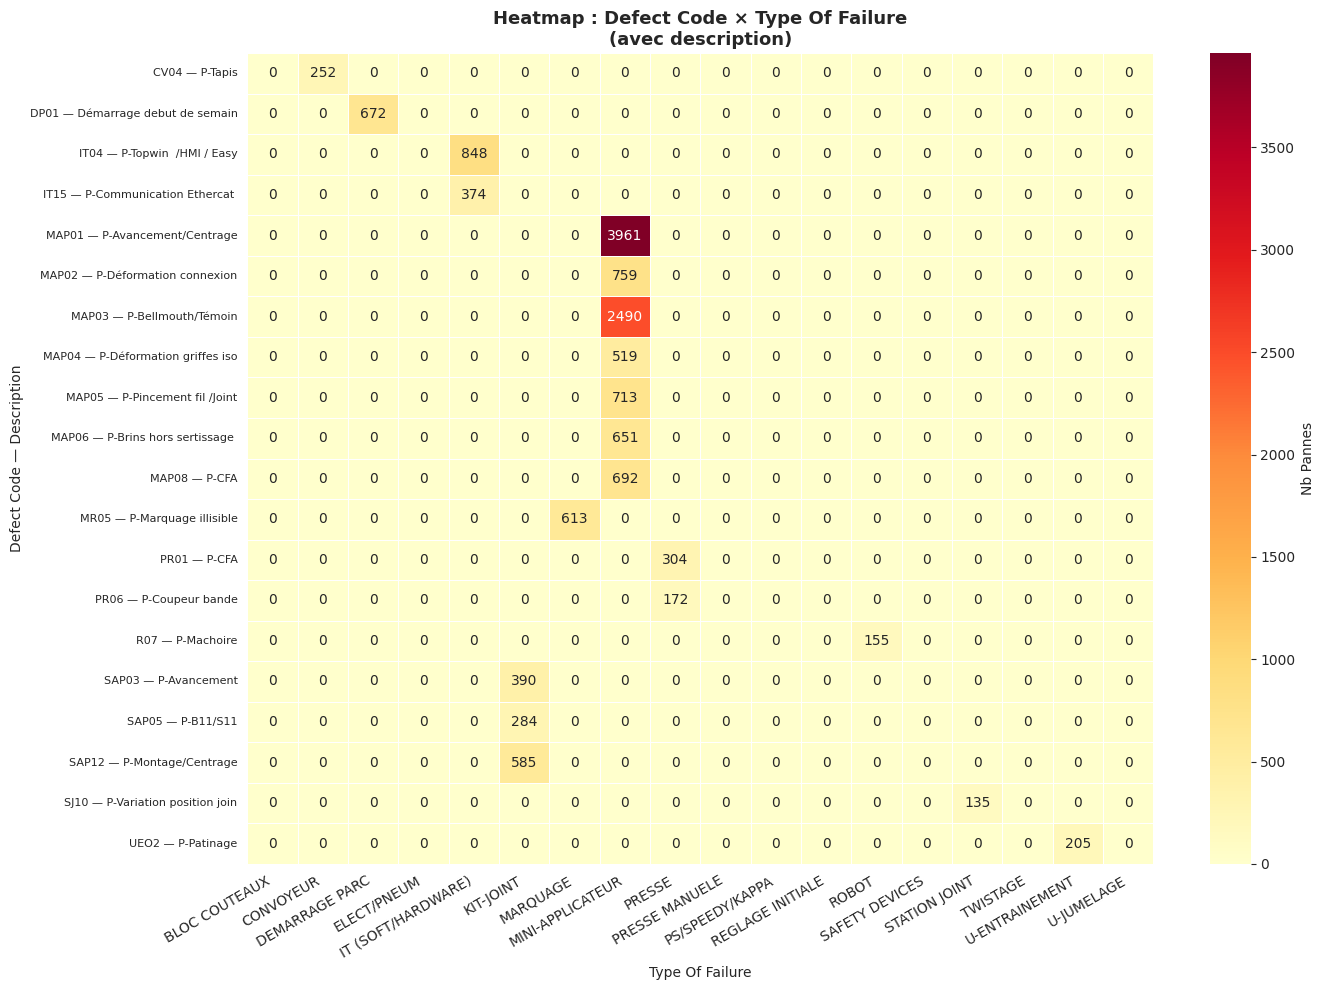

In [31]:
# ── Version 3 : Heatmap Defect Code × Type ─────
pivot_heat = (DataKomax_Corrective
              .groupby(['Defect Code', 'Type Of Failure'])
              .size()
              .unstack(fill_value=0))

top20_idx  = (DataKomax_Corrective['Defect Code']
              .value_counts().head(20).index)
pivot_heat = pivot_heat.loc[pivot_heat.index.isin(top20_idx)]

# Ajouter colonne description
desc_map = (DataKomax_Corrective
            .groupby('Defect Code')['Microstop Description']
            .first().to_dict())

pivot_heat.index = [
    f"{code} — {desc_map.get(code, '')[:25]}"
    for code in pivot_heat.index
]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_heat,
            annot=True, fmt='d',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Nb Pannes'})

plt.title('Heatmap : Defect Code × Type Of Failure\n'
           '(avec description)',
           fontsize=13, fontweight='bold')
plt.xlabel('Type Of Failure')
plt.ylabel('Defect Code — Description')
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('defects_heatmap.png', dpi=150)
plt.show()

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Préparer les données ────────────────────────
kpi_tech = DataKomax_Corrective.groupby(
    ['Technicien_Nom', 'Equipe', 'Chef_Equipe']
).agg(
    Nb_Interventions        = ('Down Time (min)', 'count'),
    Down_Time_Moyen         = ('Down Time (min)', 'mean'),
    Down_Time_Total         = ('Down Time (min)', 'sum'),
    Intervention_Time_Moyen = ('Intervention Time (min)', 'mean'),
    Waiting_Time_Moyen      = ('Waiting Time (min)', 'mean'),
).round(2).reset_index()

kpi_equipe = DataKomax_Corrective.groupby(
    ['Equipe', 'Chef_Equipe']
).agg(
    Nb_Interventions        = ('Down Time (min)', 'count'),
    Down_Time_Moyen         = ('Down Time (min)', 'mean'),
    Down_Time_Total         = ('Down Time (min)', 'sum'),
    Intervention_Time_Moyen = ('Intervention Time (min)', 'mean'),
    Waiting_Time_Moyen      = ('Waiting Time (min)', 'mean'), # Added this line
    Nb_Techniciens          = ('Technicien_Nom', 'nunique'),
).round(2).reset_index()

# Couleurs par équipe
COLORS = {
    'Equipe_1': '#3498db',
    'Equipe_2': '#2ecc71',
    'Equipe_3': '#e74c3c'
}
def get_color(equipe):
    return COLORS.get(equipe, '#95a5a6')

/tmp/ipykernel_4566/1184649962.py:105: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4566/1184649962.py:106: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.savefig('equipes_chefs_kpis.png', dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


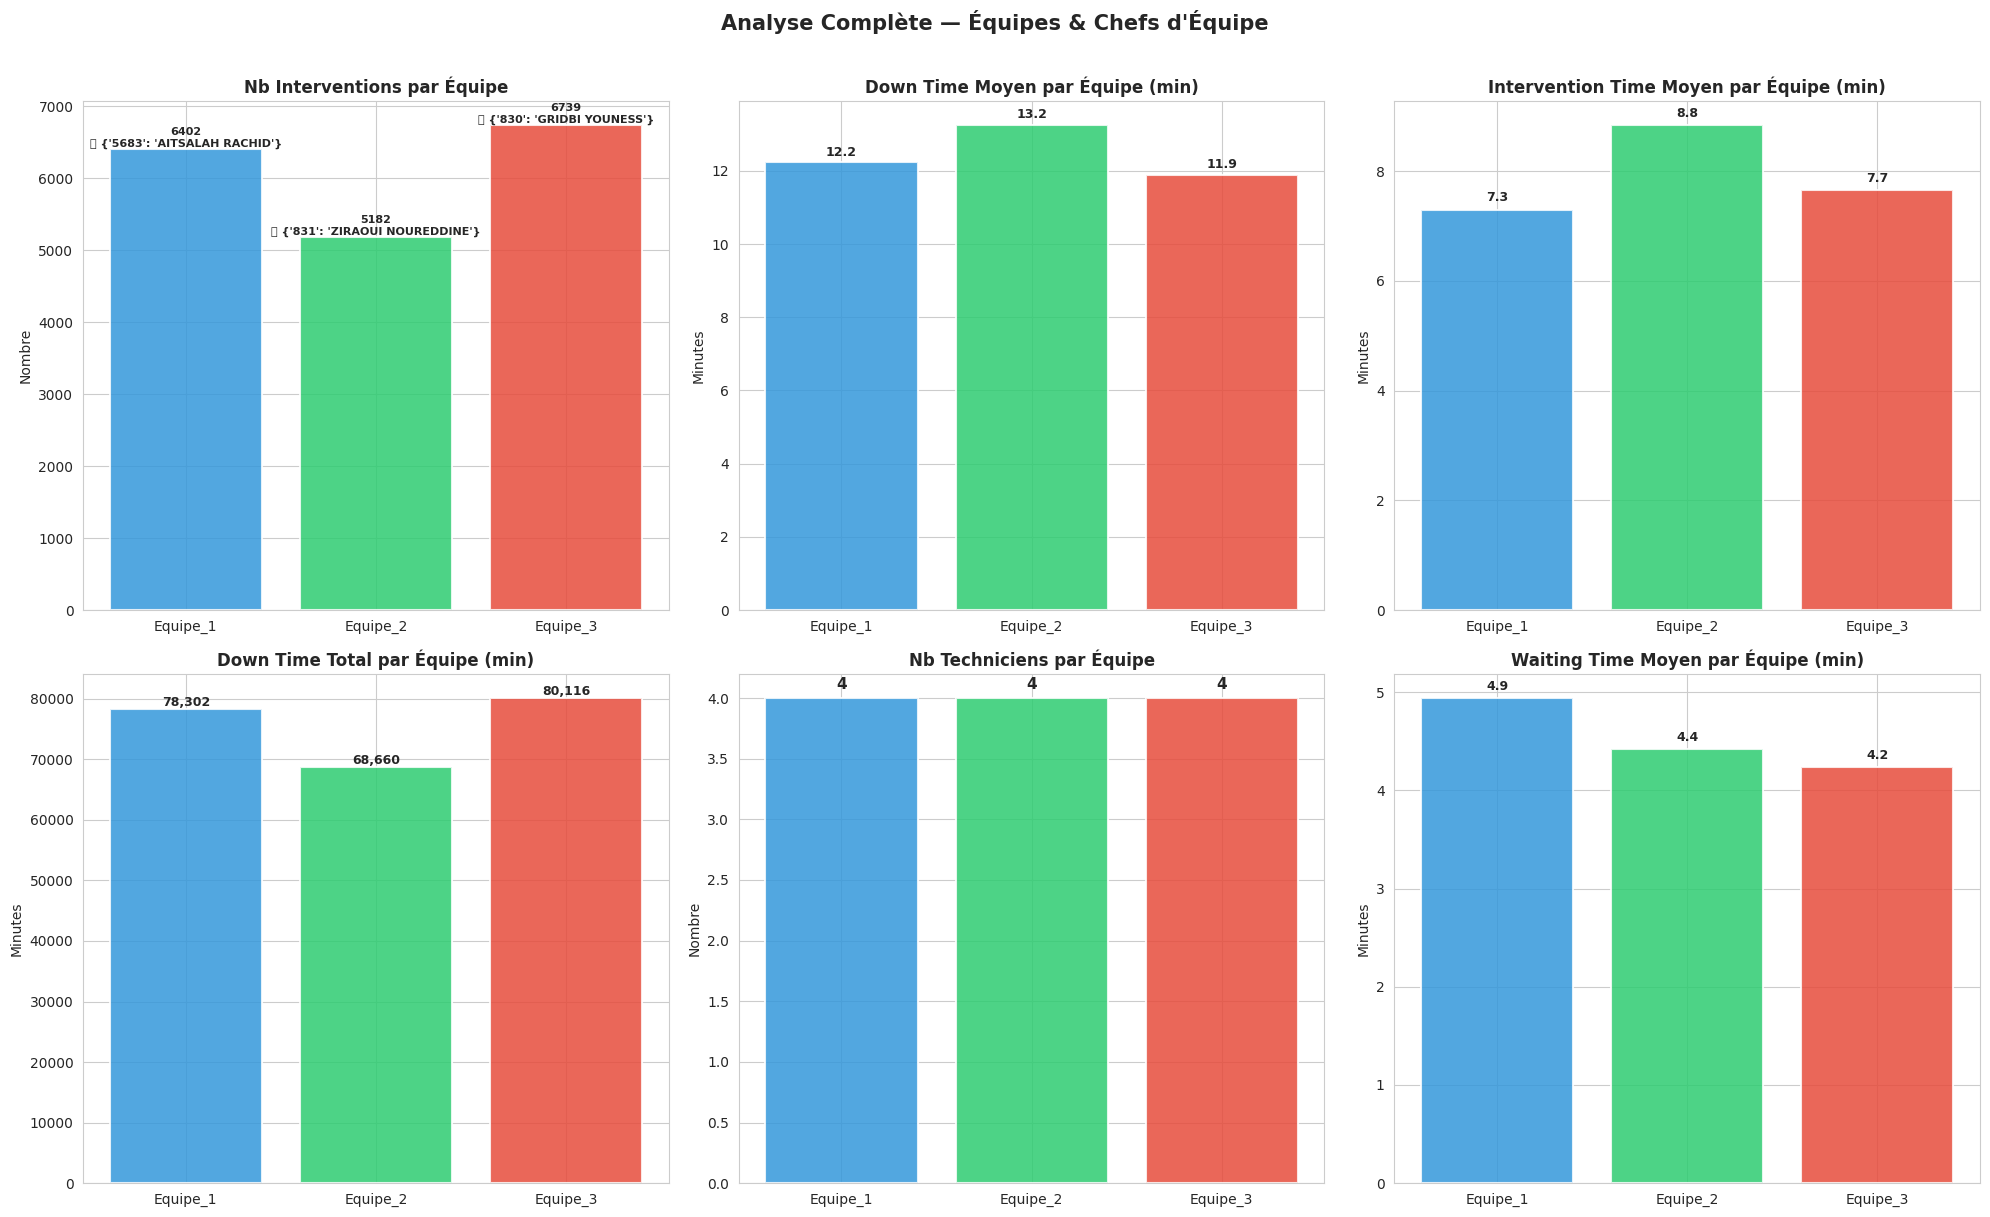

In [36]:
# ================================================
# GRAPHE 1 : Vue globale Équipe + Chef
# ================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Analyse Complète — Équipes & Chefs d\'Équipe',
              fontsize=15, fontweight='bold', y=1.01)

colors_eq = [get_color(e) for e in kpi_equipe['Equipe']]

# 1A. Nb interventions par équipe
ax = axes[0, 0]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Nb_Interventions'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Nb Interventions par Équipe',
              fontweight='bold')
ax.set_ylabel('Nombre')
for bar, val, chef in zip(
        bars,
        kpi_equipe['Nb_Interventions'],
        kpi_equipe['Chef_Equipe']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{int(val)}\n👷 {chef}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold')

# 1B. Down Time Moyen par équipe
ax = axes[0, 1]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Down_Time_Moyen'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Down Time Moyen par Équipe (min)',
              fontweight='bold')
ax.set_ylabel('Minutes')
for bar, val in zip(bars, kpi_equipe['Down_Time_Moyen']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.1f}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

# 1C. Intervention Time Moyen par équipe
ax = axes[0, 2]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Intervention_Time_Moyen'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Intervention Time Moyen par Équipe (min)',
              fontweight='bold')
ax.set_ylabel('Minutes')
for bar, val in zip(bars,
                    kpi_equipe['Intervention_Time_Moyen']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.1f}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

# 1D. Down Time Total par équipe
ax = axes[1, 0]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Down_Time_Total'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Down Time Total par Équipe (min)',
              fontweight='bold')
ax.set_ylabel('Minutes')
for bar, val in zip(bars, kpi_equipe['Down_Time_Total']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{int(val):,}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

# 1E. Nb Techniciens par équipe
ax = axes[1, 1]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Nb_Techniciens'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Nb Techniciens par Équipe',
              fontweight='bold')
ax.set_ylabel('Nombre')
for bar, val in zip(bars, kpi_equipe['Nb_Techniciens']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            str(int(val)), ha='center',
            va='bottom', fontsize=11, fontweight='bold')

# 1F. Waiting Time Moyen par équipe
ax = axes[1, 2]
bars = ax.bar(kpi_equipe['Equipe'],
              kpi_equipe['Waiting_Time_Moyen'],
              color=colors_eq, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Waiting Time Moyen par Équipe (min)',
              fontweight='bold')
ax.set_ylabel('Minutes')
for bar, val in zip(bars, kpi_equipe['Waiting_Time_Moyen']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.1f}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('equipes_chefs_kpis.png', dpi=150,
            bbox_inches='tight')
plt.show()

/tmp/ipykernel_4566/3422094110.py:74: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4566/3422094110.py:75: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  plt.savefig('techniciens_par_equipe.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128119 (\N{CONSTRUCTION WORKER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


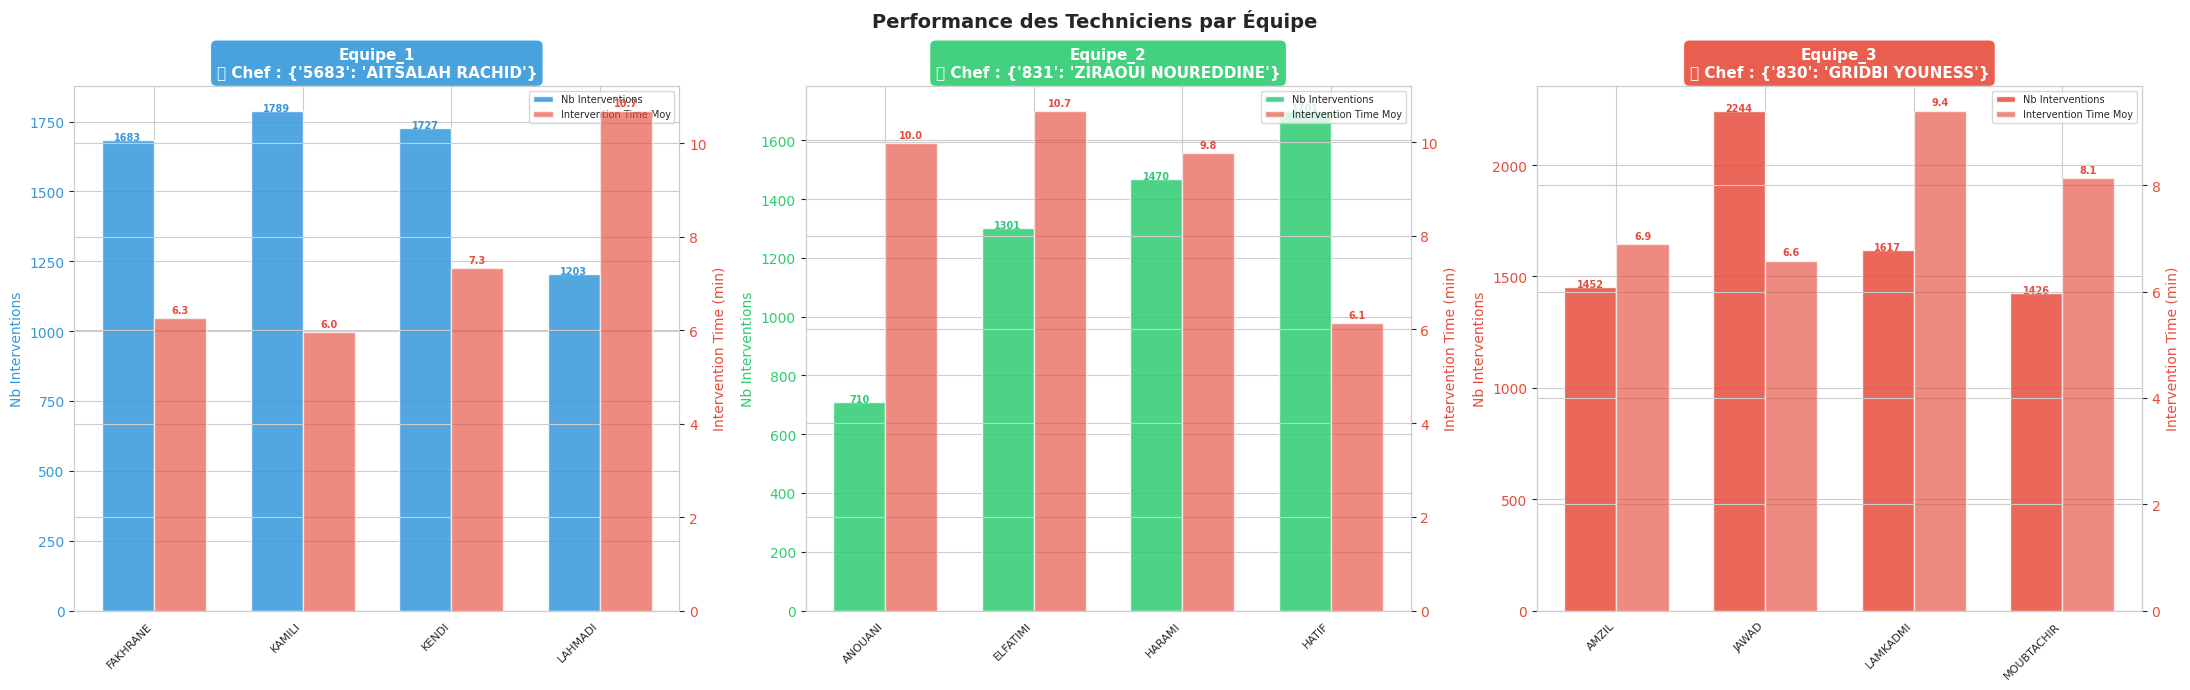

In [37]:
# ================================================
# GRAPHE 2 : Performance Techniciens par Équipe
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7),
                          sharey=False)
fig.suptitle('Performance des Techniciens par Équipe',
              fontsize=14, fontweight='bold')

for i, equipe in enumerate(
        sorted(DataKomax_Corrective['Equipe'].unique())):

    ax    = axes[i]
    data  = kpi_tech[kpi_tech['Equipe'] == equipe].copy()
    chef  = data['Chef_Equipe'].iloc[0] if len(data) > 0 else ''
    color = get_color(equipe)

    if len(data) == 0:
        ax.set_visible(False)
        continue

    x     = np.arange(len(data))
    width = 0.35
    ax2   = ax.twinx()

    # Nb interventions
    b1 = ax.bar(x - width/2,
                data['Nb_Interventions'],
                width=width, color=color,
                alpha=0.85, label='Nb Interventions',
                edgecolor='white')

    # Intervention Time
    b2 = ax2.bar(x + width/2,
                  data['Intervention_Time_Moyen'],
                  width=width, color='#e74c3c',
                  alpha=0.65,
                  label='Intervention Time Moy',
                  edgecolor='white')

    # Valeurs
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha='center', fontsize=7,
                color=color, fontweight='bold')
    for bar in b2:
        ax2.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.1,
                  f'{bar.get_height():.1f}',
                  ha='center', fontsize=7,
                  color='#e74c3c', fontweight='bold')

    ax.set_title(f'{equipe}\n👷 Chef : {chef}',
                  fontweight='bold', fontsize=11,
                  color='white',
                  bbox=dict(boxstyle='round,pad=0.4',
                            facecolor=color, alpha=0.9))
    ax.set_xticks(x)
    ax.set_xticklabels(data['Technicien_Nom'],
                        rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Nb Interventions', color=color)
    ax2.set_ylabel('Intervention Time (min)',
                    color='#e74c3c')
    ax.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelcolor='#e74c3c')

    # Légende
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, l1 + l2,
               loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('techniciens_par_equipe.png', dpi=150)
plt.show()

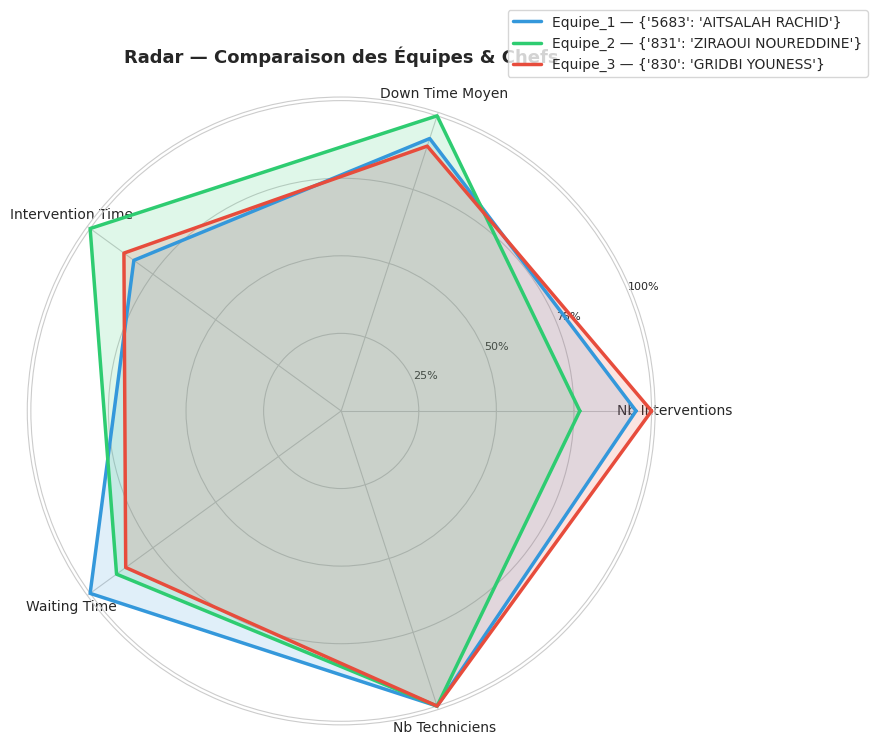

In [38]:
# ================================================
# GRAPHE 3 : Radar Chart — Comparaison Équipes
# ================================================
categories = ['Nb Interventions', 'Down Time Moyen',
              'Intervention Time', 'Waiting Time',
              'Nb Techniciens']

# Normaliser 0-1
kpi_norm = kpi_equipe.copy()
for col, cat in zip(
    ['Nb_Interventions', 'Down_Time_Moyen',
     'Intervention_Time_Moyen', 'Waiting_Time_Moyen',
     'Nb_Techniciens'],
    categories
):
    mx = kpi_norm[col].max()
    kpi_norm[col] = kpi_norm[col] / mx if mx > 0 else 0

N     = len(categories)
theta = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
theta += theta[:1]

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw=dict(polar=True))

for _, row in kpi_norm.iterrows():
    equipe = row['Equipe']
    chef   = row['Chef_Equipe']
    color  = get_color(equipe)
    values = [
        row['Nb_Interventions'],
        row['Down_Time_Moyen'],
        row['Intervention_Time_Moyen'],
        row['Waiting_Time_Moyen'],
        row['Nb_Techniciens'],
    ]
    values += values[:1]
    ax.plot(theta, values, linewidth=2.5,
             color=color,
             label=f'{equipe} — {chef}')
    ax.fill(theta, values, color=color, alpha=0.15)

ax.set_xticks(theta[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'],
                    fontsize=8)
ax.set_title('Radar — Comparaison des Équipes & Chefs',
              fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right',
           bbox_to_anchor=(1.35, 1.15),
           fontsize=10)
plt.tight_layout()
plt.savefig('radar_equipes.png', dpi=150)
plt.show()

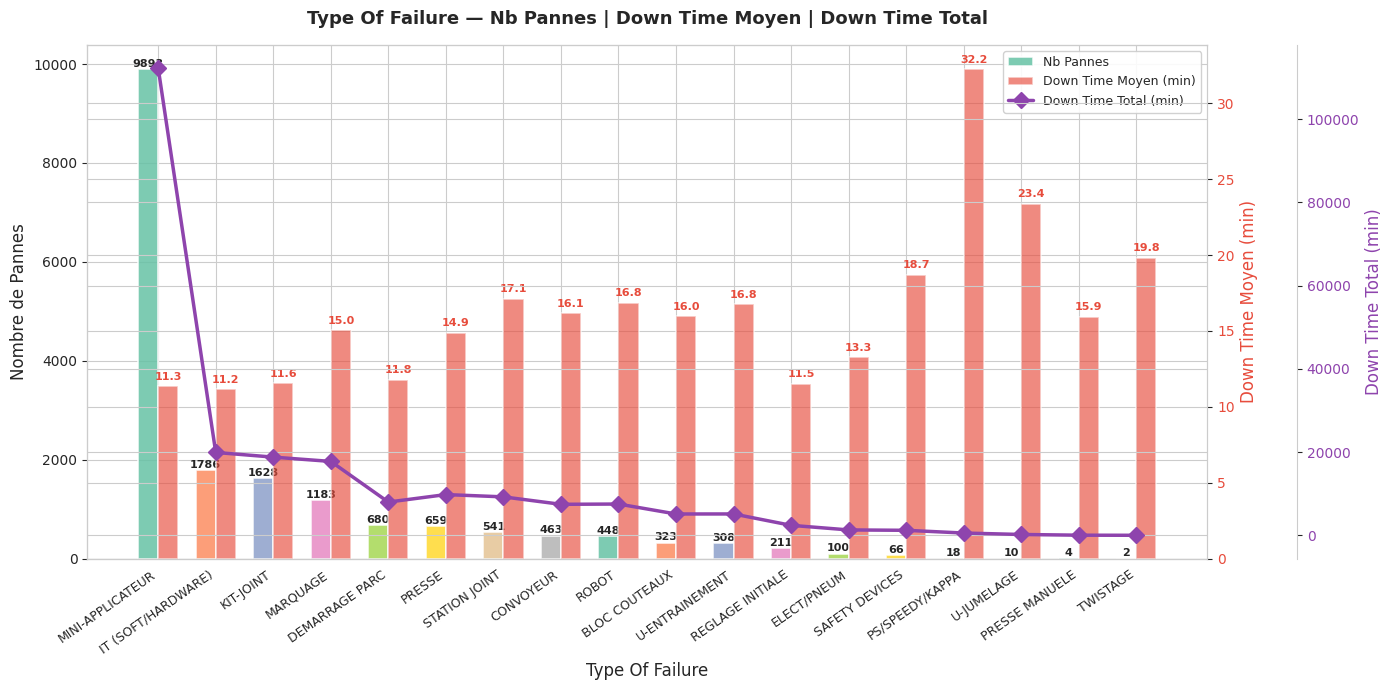

In [39]:
# ================================================
# GRAPHE : Type Of Failure — Down Time + Nb Pannes
# ================================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Préparer données
type_stats = DataKomax_Corrective.groupby(
    'Type Of Failure'
).agg(
    Nb_Pannes  = ('Down Time (min)', 'count'),
    Down_Time  = ('Down Time (min)', 'mean'),
    Down_Total = ('Down Time (min)', 'sum'),
).reset_index().sort_values('Nb_Pannes', ascending=False)

x      = np.arange(len(type_stats))
width  = 0.35
colors = sns.color_palette('Set2', len(type_stats))

# Axe gauche : Nb Pannes
bars1 = ax1.bar(x - width/2,
                 type_stats['Nb_Pannes'],
                 width=width,
                 color=[c for c in colors],
                 alpha=0.85,
                 label='Nb Pannes',
                 edgecolor='white', linewidth=1.2)
ax1.set_ylabel('Nombre de Pannes', fontsize=12)
ax1.set_xlabel('Type Of Failure', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)

# Valeurs barres Nb Pannes
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 5,
              str(int(bar.get_height())),
              ha='center', va='bottom',
              fontsize=8, fontweight='bold')

# Axe droit : Down Time Moyen
ax2   = ax1.twinx()
bars2 = ax2.bar(x + width/2,
                 type_stats['Down_Time'],
                 width=width,
                 color='#e74c3c',
                 alpha=0.65,
                 label='Down Time Moyen (min)',
                 edgecolor='white', linewidth=1.2)
ax2.set_ylabel('Down Time Moyen (min)', fontsize=12,
               color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Valeurs barres Down Time
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3,
              f'{bar.get_height():.1f}',
              ha='center', va='bottom',
              fontsize=8, fontweight='bold',
              color='#e74c3c')

# Ligne Down Time Total
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.08))
ax3.plot(x, type_stats['Down_Total'],
          color='#8e44ad', marker='D',
          linewidth=2.5, markersize=8,
          label='Down Time Total (min)',
          zorder=5)
ax3.set_ylabel('Down Time Total (min)',
               fontsize=12, color='#8e44ad')
ax3.tick_params(axis='y', labelcolor='#8e44ad')

# Labels x
ax1.set_xticks(x)
ax1.set_xticklabels(type_stats['Type Of Failure'],
                     rotation=35, ha='right', fontsize=9)

# Titre
plt.title('Type Of Failure — Nb Pannes | '
           'Down Time Moyen | Down Time Total',
           fontsize=13, fontweight='bold', pad=15)

# Légende combinée
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
lines3, l3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3,
            l1 + l2 + l3,
            loc='upper right', fontsize=9,
            framealpha=0.9)

plt.tight_layout()
plt.savefig('type_failure_complet.png', dpi=150)
plt.show()

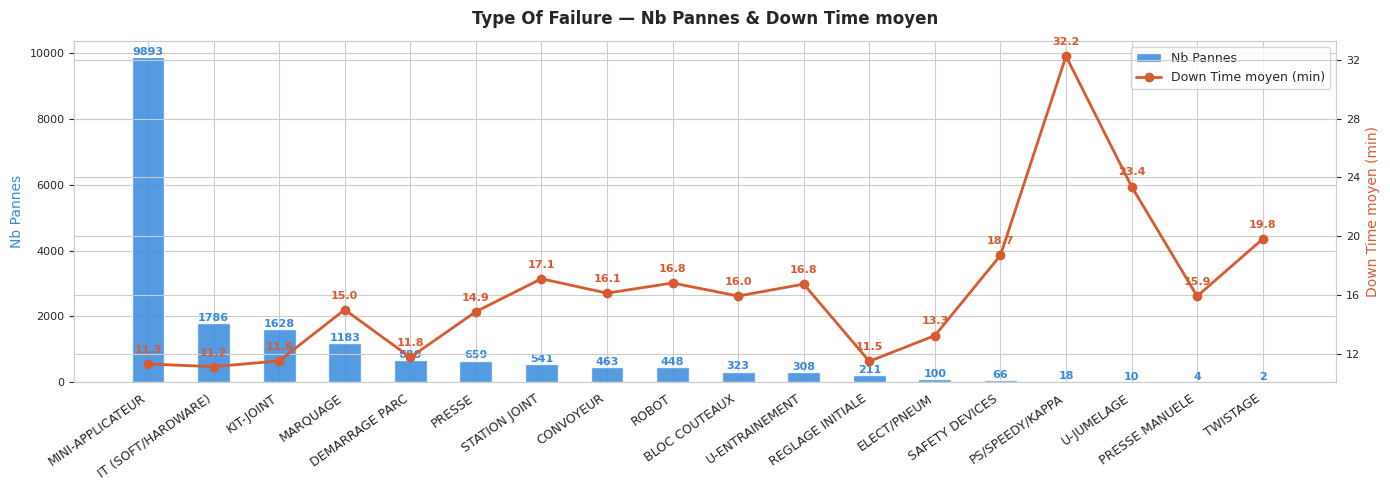

✅ type_failure_nb_downtime.png sauvegardé


In [40]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 1 : Type Of Failure — Nb Pannes + Down Time
# ════════════════════════════════════════════════════════════
summary = DataKomax_Corrective.groupby('Type Of Failure').agg(
    Nb_Pannes   = ('Type Of Failure', 'count'),
    Down_Time   = ('Down Time (min)', 'mean')
).sort_values('Nb_Pannes', ascending=False).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
x     = range(len(summary))
width = 0.5

bars = ax1.bar(x, summary['Nb_Pannes'],
               color='#378ADD', alpha=0.85,
               width=width, label='Nb Pannes')

for bar, val in zip(bars, summary['Nb_Pannes']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(val), ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#378ADD')

ax2 = ax1.twinx()
ax2.plot(x, summary['Down_Time'],
         color='#D85A30', marker='o',
         linewidth=2, markersize=6,
         label='Down Time moyen (min)')

for i, val in enumerate(summary['Down_Time']):
    ax2.annotate(f'{val:.1f}',
                 xy=(i, val),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8,
                 color='#D85A30', fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(summary['Type Of Failure'],
                    rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('Nb Pannes', color='#378ADD', fontsize=10)
ax2.set_ylabel('Down Time moyen (min)', color='#D85A30', fontsize=10)
ax1.set_title('Type Of Failure — Nb Pannes & Down Time moyen',
              fontsize=12, fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=9)

ax1.yaxis.set_major_locator(plt.MaxNLocator(6))
ax2.yaxis.set_major_locator(plt.MaxNLocator(6))
ax1.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('type_failure_nb_downtime.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ type_failure_nb_downtime.png sauvegardé")

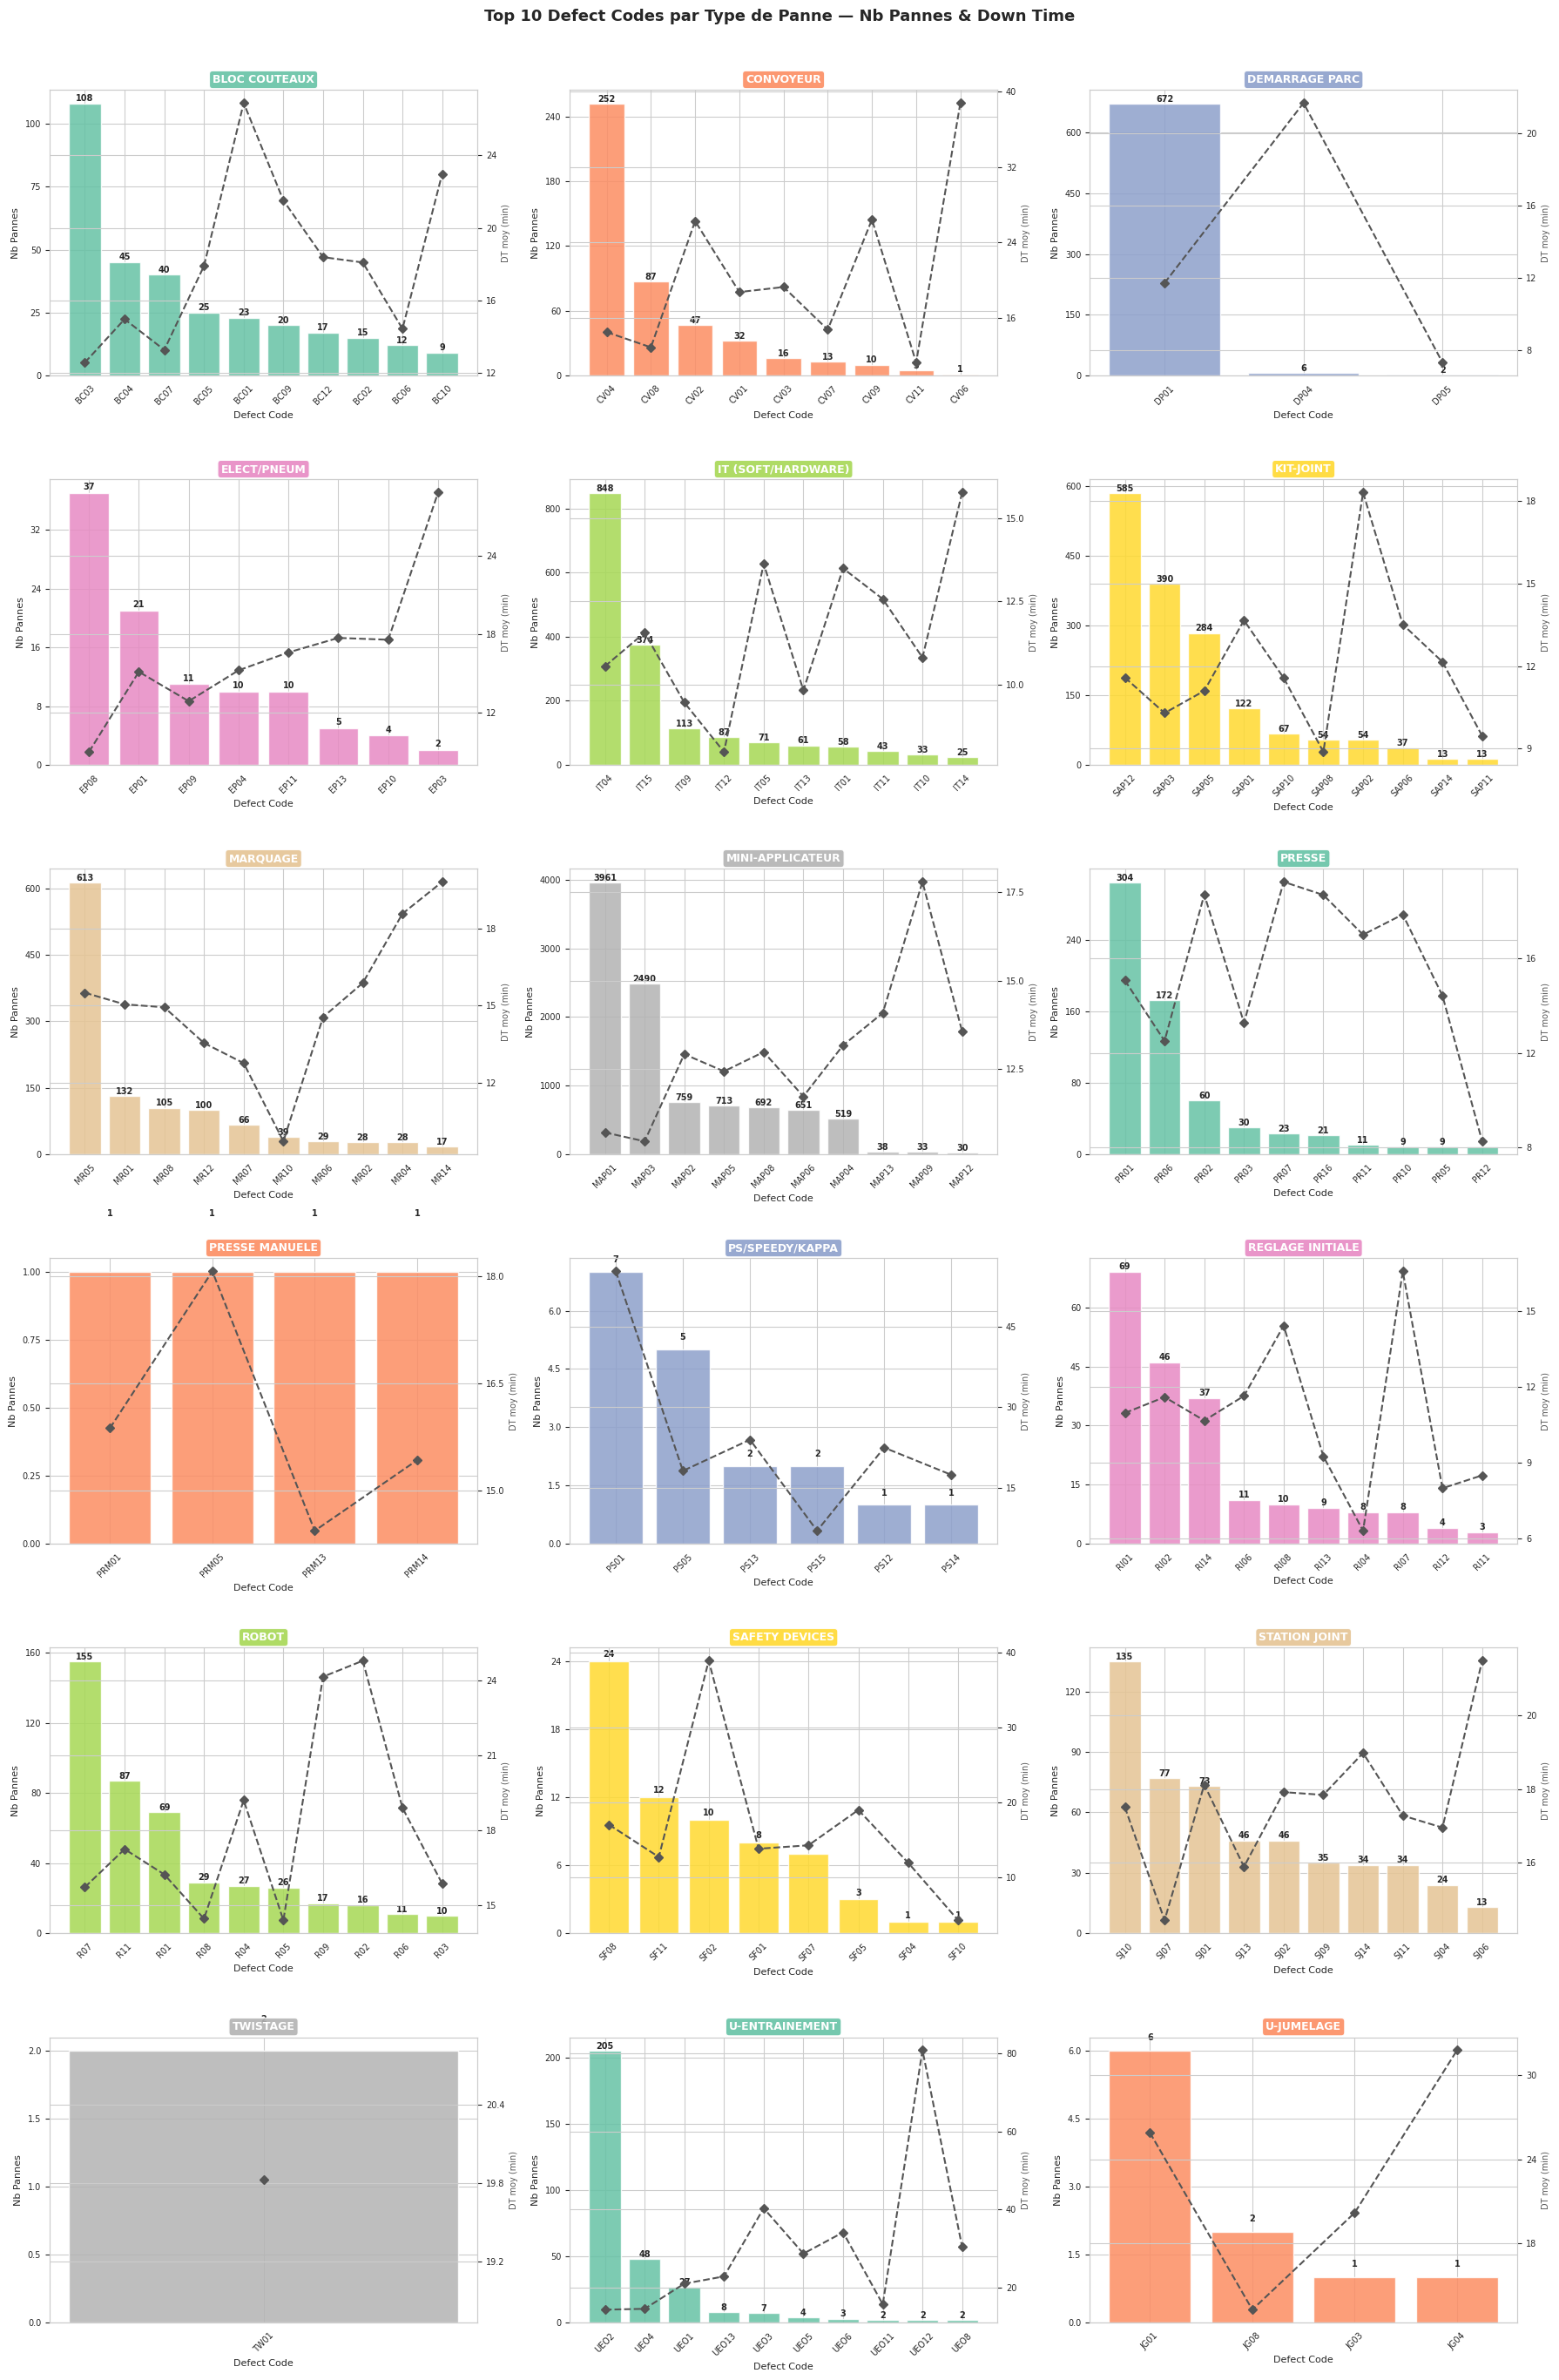

✅ defects_par_type_complet.png sauvegardé


In [41]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 2 : Top 10 Defect Codes par Type Of Failure
#             (Nb Pannes + Down Time moyen sur chaque barre)
# ════════════════════════════════════════════════════════════
types  = sorted(DataKomax_Corrective['Type Of Failure'].unique())
n      = len(types)
cols   = 3
rows   = (n + cols - 1) // cols
colors = sns.color_palette('Set2', n)

fig, axes = plt.subplots(rows, cols,
                          figsize=(18, rows * 4.5))
axes = axes.flatten()

for i, type_panne in enumerate(types):
    ax   = axes[i]
    data = DataKomax_Corrective[DataKomax_Corrective['Type Of Failure'] == type_panne]

    agg = (data.groupby('Defect Code')
               .agg(Nb=('Defect Code','count'),
                    DT=('Down Time (min)','mean'))
               .sort_values('Nb', ascending=False)
               .head(10))

    if len(agg) == 0:
        ax.set_visible(False)
        continue

    bars = ax.bar(agg.index, agg['Nb'],
                  color=colors[i], alpha=0.85, edgecolor='white')

    ax2 = ax.twinx()
    ax2.plot(range(len(agg)), agg['DT'],
             color='#555', marker='D',
             linewidth=1.5, markersize=5, linestyle='--',
             label='DT moyen')
    ax2.set_ylabel('DT moy (min)', fontsize=7,
                   color='#555')
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_locator(plt.MaxNLocator(4))

    for bar, val in zip(bars, agg['Nb']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                str(val), ha='center', va='bottom',
                fontsize=7, fontweight='bold')

    ax.set_title(type_panne, fontweight='bold',
                 fontsize=9, color='white',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor=colors[i], alpha=0.9))
    ax.set_xlabel('Defect Code', fontsize=8)
    ax.set_ylabel('Nb Pannes', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Defect Codes par Type de Panne — Nb Pannes & Down Time',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('defects_par_type_complet.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ defects_par_type_complet.png sauvegardé")



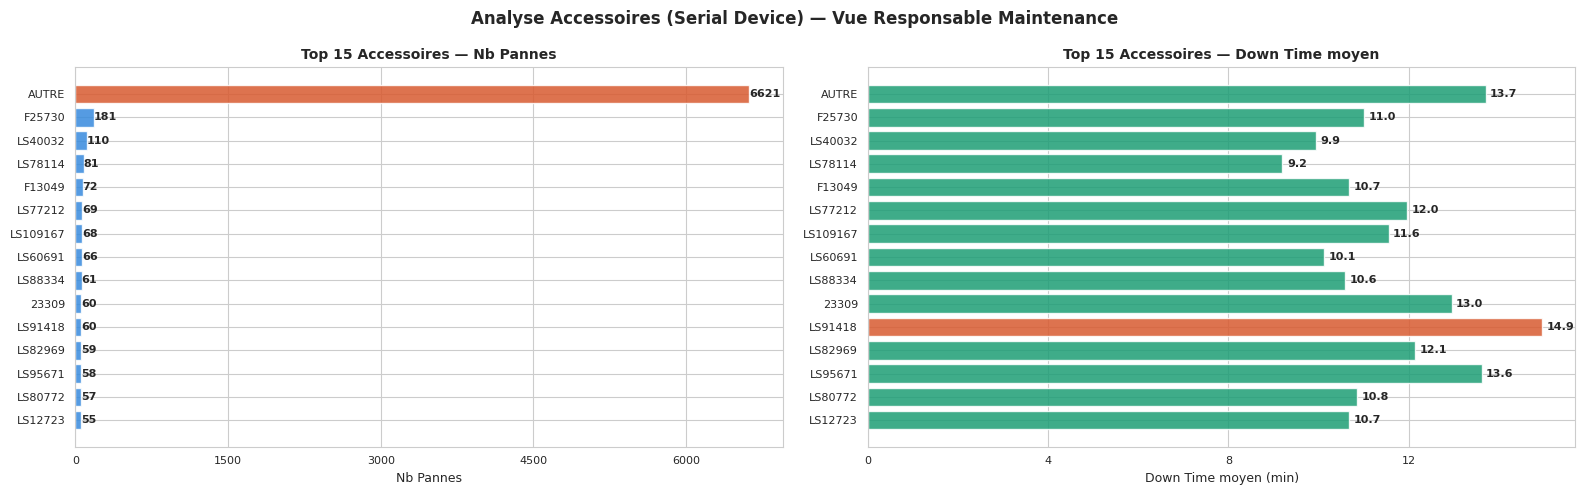

✅ accessoire_analyse.png sauvegardé


In [42]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 3 : Analyse Accessoire (Serial Device)
#             Top 15 accessoires — Nb Pannes + Down Time
# ════════════════════════════════════════════════════════════
acc = (DataKomax_Corrective.groupby('Serial Device')
         .agg(Nb_Pannes  = ('Serial Device','count'),
              Down_Time  = ('Down Time (min)','mean'),
              Type_Panne = ('Type Of Failure', lambda x: x.mode()[0]))
         .sort_values('Nb_Pannes', ascending=False)
         .head(15)
         .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Subplot A : Nb Pannes horizontal
colors_acc = ['#D85A30' if nb == acc['Nb_Pannes'].max()
              else '#378ADD' for nb in acc['Nb_Pannes']]

bars = axes[0].barh(acc['Serial Device'], acc['Nb_Pannes'],
                    color=colors_acc, alpha=0.85)
for bar, val in zip(bars, acc['Nb_Pannes']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=8, fontweight='bold')

axes[0].set_xlabel('Nb Pannes', fontsize=9)
axes[0].set_title('Top 15 Accessoires — Nb Pannes',
                  fontsize=10, fontweight='bold')
axes[0].tick_params(labelsize=8)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(5))
axes[0].invert_yaxis()

# -- Subplot B : Down Time moyen
colors_dt = ['#D85A30' if dt == acc['Down_Time'].max()
             else '#1D9E75' for dt in acc['Down_Time']]

bars2 = axes[1].barh(acc['Serial Device'], acc['Down_Time'],
                     color=colors_dt, alpha=0.85)
for bar, val in zip(bars2, acc['Down_Time']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8, fontweight='bold')

axes[1].set_xlabel('Down Time moyen (min)', fontsize=9)
axes[1].set_title('Top 15 Accessoires — Down Time moyen',
                  fontsize=10, fontweight='bold')
axes[1].tick_params(labelsize=8)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(5))
axes[1].invert_yaxis()

plt.suptitle('Analyse Accessoires (Serial Device) — Vue Responsable Maintenance',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('accessoire_analyse.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ accessoire_analyse.png sauvegardé")



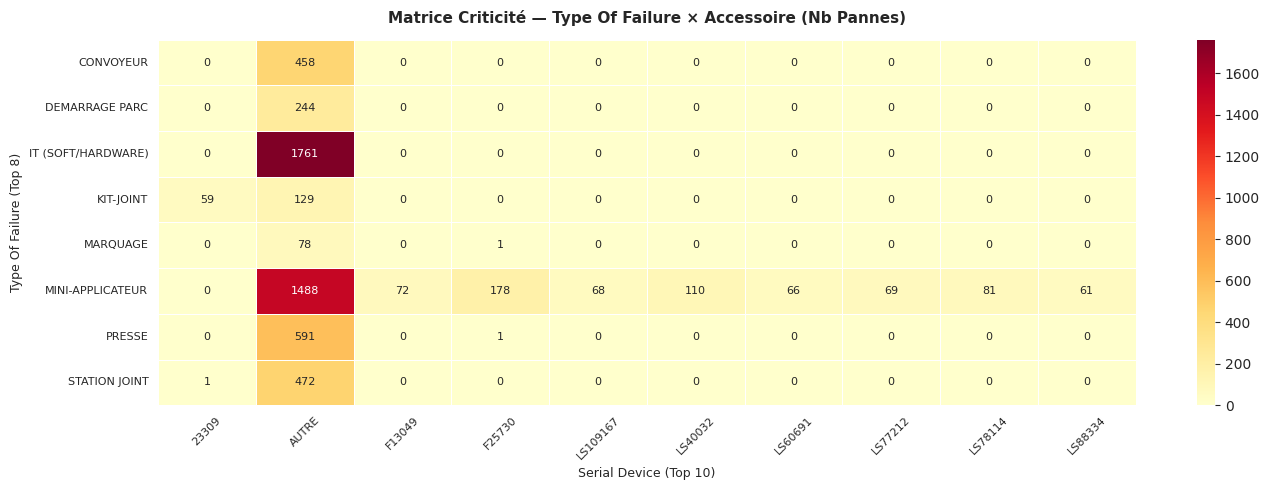

✅ matrice_criticite.png sauvegardé


In [43]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 4 : Matrice Criticité — Type Of Failure vs Accessoire
#             (Heatmap Nb Pannes)
# ════════════════════════════════════════════════════════════
top_acc   = DataKomax_Corrective['Serial Device'].value_counts().head(10).index
top_types = DataKomax_Corrective['Type Of Failure'].value_counts().head(8).index

matrix = (DataKomax_Corrective[DataKomax_Corrective['Serial Device'].isin(top_acc) &
              DataKomax_Corrective['Type Of Failure'].isin(top_types)]
            .groupby(['Type Of Failure','Serial Device'])
            .size()
            .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(matrix,
            annot=True, fmt='d',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matrice Criticité — Type Of Failure × Accessoire (Nb Pannes)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Serial Device (Top 10)', fontsize=9)
ax.set_ylabel('Type Of Failure (Top 8)', fontsize=9)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('matrice_criticite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ matrice_criticite.png sauvegardé")



/tmp/ipykernel_4566/1606589565.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=DataKomax_Corrective_plot,
/tmp/ipykernel_4566/1606589565.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),


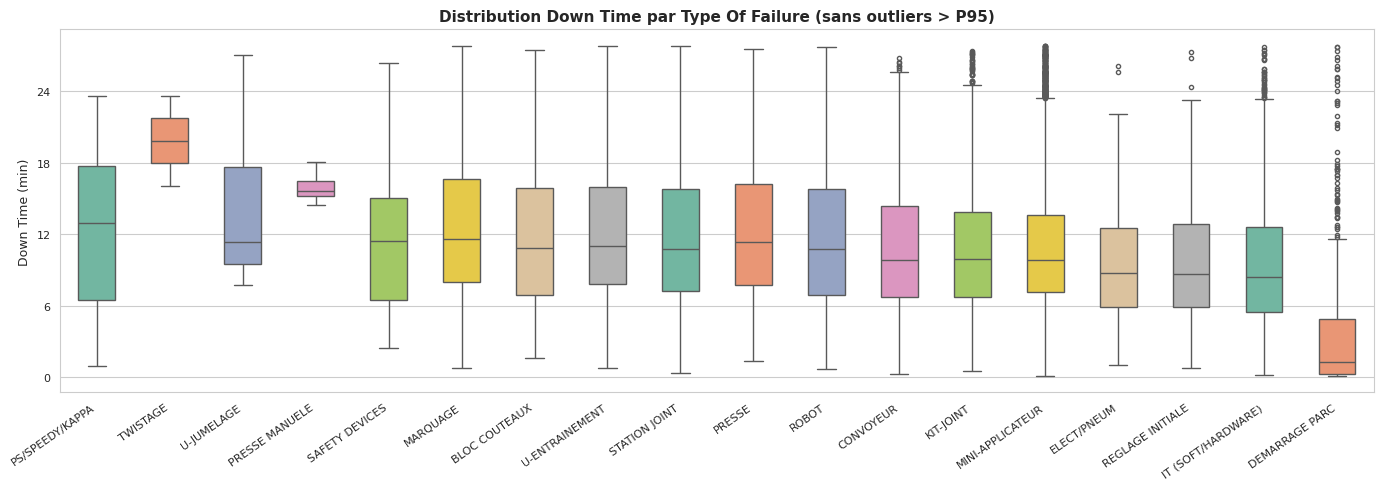

✅ boxplot_downtime_type.png sauvegardé

✅ Tous les graphes sauvegardés !


In [44]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 5 : Boxplot Down Time par Type Of Failure
#             (Voir la dispersion — utile pour le responsable)
# ════════════════════════════════════════════════════════════
order = (DataKomax_Corrective.groupby('Type Of Failure')['Down Time (min)']
           .median()
           .sort_values(ascending=False)
           .index)

# Couper les outliers extrêmes pour lisibilité
p95 = DataKomax_Corrective['Down Time (min)'].quantile(0.95)
DataKomax_Corrective_plot = DataKomax_Corrective[DataKomax_Corrective['Down Time (min)'] <= p95]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=DataKomax_Corrective_plot,
            x='Type Of Failure',
            y='Down Time (min)',
            order=order,
            palette='Set2',
            width=0.5,
            fliersize=3,
            ax=ax)

ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Down Time (min)', fontsize=9)
ax.set_xlabel('')
ax.set_title('Distribution Down Time par Type Of Failure (sans outliers > P95)',
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('boxplot_downtime_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ boxplot_downtime_type.png sauvegardé")

print("\n✅ Tous les graphes sauvegardés !")

/tmp/ipykernel_4566/4234627039.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(labels_unique))


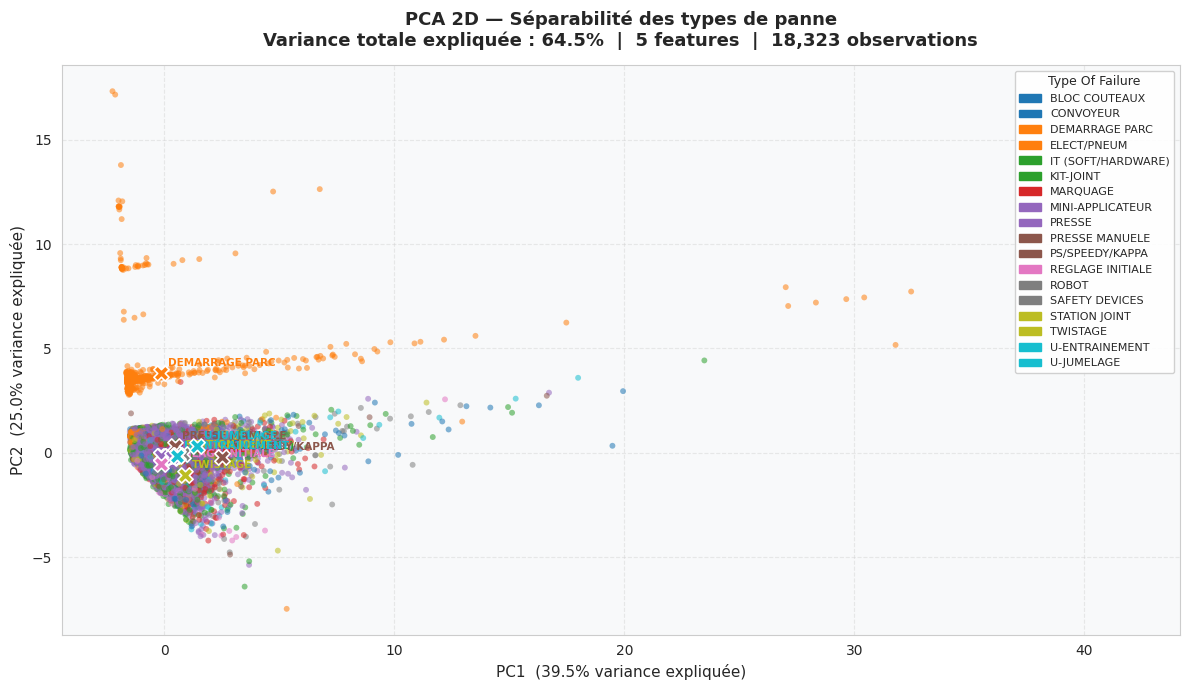

Variance expliquée  : PC1=39.5%  PC2=25.0%  Total=64.5%
Features utilisées  : ['Down Time (min)', 'Reaction Time (min)', 'Waiting Time (min)', 'Intervention Time (min)', 'Hour']
Observations        : 18,323
✅ Graphe sauvegardé : pca_2d_type_panne.png


In [45]:
# ════════════════════════════════════════════════════════════
#  GRAPHE 6 : PCA 2D — Séparabilité des types de panne
#             (Visualisation pour la soutenance)
# ════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colonnes numériques disponibles dans DataKomax_Corrective ──
NUM_COLS = [c for c in [
    'Down Time (min)', 'Reaction Time (min)',
    'Waiting Time (min)', 'Intervention Time (min)',
    'Hour', 'DayOfWeek', 'WeekOfYear'
] if c in DataKomax_Corrective.columns]

df_pca = DataKomax_Corrective[NUM_COLS + ['Type Of Failure']].dropna()

X_raw  = df_pca[NUM_COLS].values
y_raw  = df_pca['Type Of Failure'].values

# ── Standardisation + PCA ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
var_total = var1 + var2

# ── Palette couleurs ──
labels_unique = sorted(set(y_raw))
cmap = plt.cm.get_cmap('tab10', len(labels_unique))
color_map = {lbl: cmap(i) for i, lbl in enumerate(labels_unique)}
colors = [color_map[lbl] for lbl in y_raw]

# ── Tracé ──
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=colors, alpha=0.55, s=18, linewidths=0
)

# Centroïdes par classe
for lbl in labels_unique:
    mask = y_raw == lbl
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(cx, cy, marker='X', s=120, color=color_map[lbl],
               edgecolors='white', linewidths=1.2, zorder=5)
    ax.annotate(lbl, (cx, cy), fontsize=7.5, fontweight='bold',
                xytext=(5, 5), textcoords='offset points',
                color=color_map[lbl])

# Légende
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels_unique]
ax.legend(handles=patches, loc='upper right', fontsize=8,
          framealpha=0.9, title='Type Of Failure', title_fontsize=9)

ax.set_xlabel(f'PC1  ({var1:.1f}% variance expliquée)', fontsize=11)
ax.set_ylabel(f'PC2  ({var2:.1f}% variance expliquée)', fontsize=11)
ax.set_title(
    f'PCA 2D — Séparabilité des types de panne\n'
    f'Variance totale expliquée : {var_total:.1f}%  |  '
    f'{len(NUM_COLS)} features  |  {len(df_pca):,} observations',
    fontsize=13, fontweight='bold', pad=14
)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('pca_2d_type_panne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance expliquée  : PC1={var1:.1f}%  PC2={var2:.1f}%  Total={var_total:.1f}%")
print(f"Features utilisées  : {NUM_COLS}")
print(f"Observations        : {len(df_pca):,}")
print("✅ Graphe sauvegardé : pca_2d_type_panne.png")
